
CATBOOST REGRESSOR - CS (MPa) PREDICTION
3D-PRINTED FIBER-REINFORCED CONCRETE

METHODOLOGY:
  - Hyperparameter optimization: RandomizedSearchCV with 5-fold KFold
  - Stability assessment: Repeated five-fold CV (5 repeats)
  - Primary interpretation: SHAP
  - Complementary importance: Permutation importance
  - Supplementary local: LIME



2026-08-14 15:56:48,569 - INFO - Loading data from: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Data\Data.csv
2026-08-14 15:56:48,580 - INFO - Initial data shape: (225, 13)
2026-08-14 15:56:48,590 - INFO - Loaded 225 samples with 12 features
2026-08-14 15:56:48,591 - INFO - Target: Min=19.5000, Max=153.4000, Mean=77.4474
2026-08-14 15:56:48,593 - INFO - Available features: ['OPC', 'Sand', 'wtob', 'FA', 'GS', 'SF', 'SP', 'HPMC', 'W', 'Fvol', 'Df', 'Lf']
2026-08-14 15:56:48,600 - INFO - Hyperparameter optimization: 150 trials
2026-08-14 15:56:48,601 - INFO - CV: 5-fold KFold with shuffling



Available features: ['OPC', 'Sand', 'wtob', 'FA', 'GS', 'SF', 'SP', 'HPMC', 'W', 'Fvol', 'Df', 'Lf']

Split completed:
  Training: 180 samples
  Test: 45 samples
  Features: ['OPC', 'Sand', 'wtob', 'FA', 'GS', 'SF', 'SP', 'HPMC', 'W', 'Fvol', 'Df', 'Lf']


2026-08-14 15:59:05,058 - INFO - Search completed in 136.4 seconds
2026-08-14 15:59:05,060 - INFO - Best CV score: 70.6672
2026-08-14 15:59:05,100 - INFO - Stability assessment: 5 folds × 5 repeats
2026-08-14 15:59:05,102 - INFO - NOTE: This assesses stability of the selected model, NOT independent generalization



Best hyperparameters:
  subsample: 0.6
  learning_rate: 0.03
  l2_leaf_reg: 5
  iterations: 300
  depth: 6
  border_count: 255
  random_seed: 42
  thread_count: 1
  verbose: False
  loss_function: RMSE
  eval_metric: RMSE


Stability: 100%|██████████| 25/25 [00:09<00:00,  2.51it/s]
2026-08-14 15:59:15,057 - INFO - Stability R² (mean ± SD): 0.9280 ± 0.0188



Stability assessment (mean ± SD across 25 repeated validation folds):
  R²: 0.9280 ± 0.0188
  RMSE: 8.4685 ± 0.7944 MPa
  MAE: 6.6769 ± 0.6669 MPa

Training final model...

Training performance (diagnostic - NOT generalization):
  R²: 0.9447
  RMSE: 7.6305 MPa
  MAE: 5.9245 MPa

Test set evaluation (primary generalization):
  R²: 0.9319
  RMSE: 9.0562 MPa
  MAE: 7.3672 MPa
  Predictions within ±10% relative error: 60.00%


Bootstrap: 100%|██████████| 2000/2000 [00:05<00:00, 340.01samples/s]



Bootstrap 95% confidence intervals for test-set performance metrics:
  R2: 0.9282 [0.8844, 0.9566]
  RMSE: 9.0045 [7.4974, 10.4576]
  MAE: 7.3560 [5.8195, 8.9167]

Generating plots...


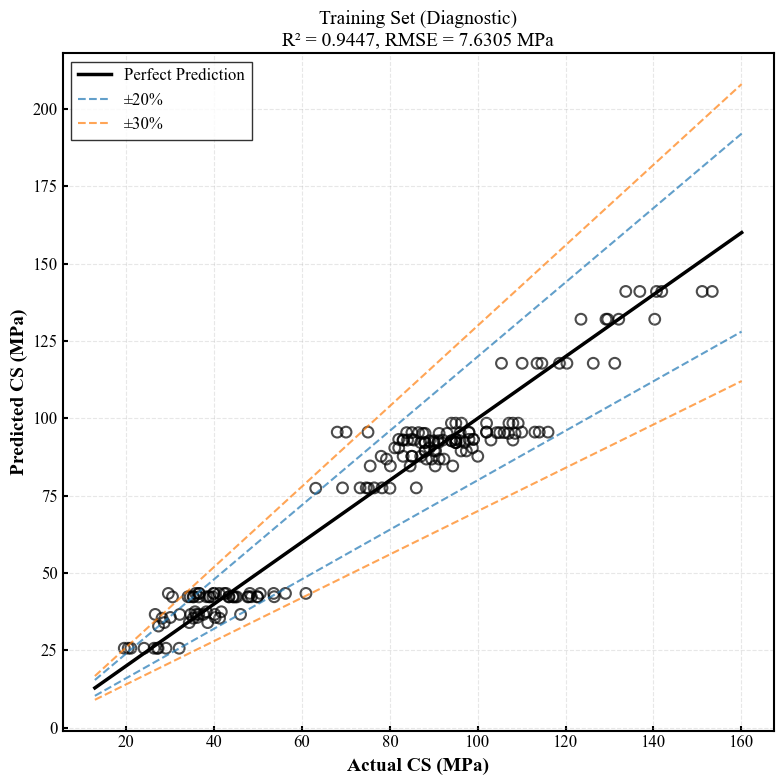

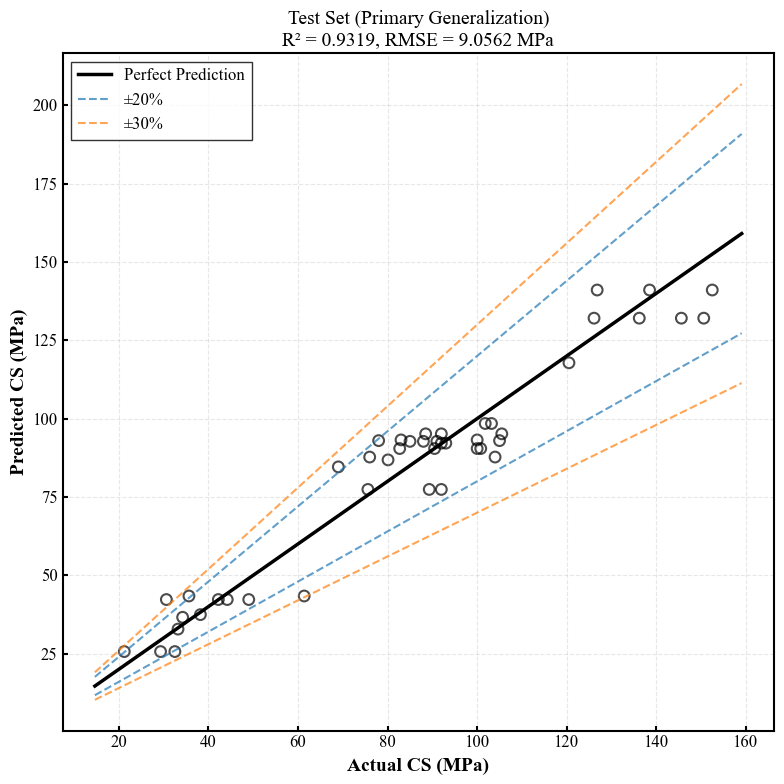

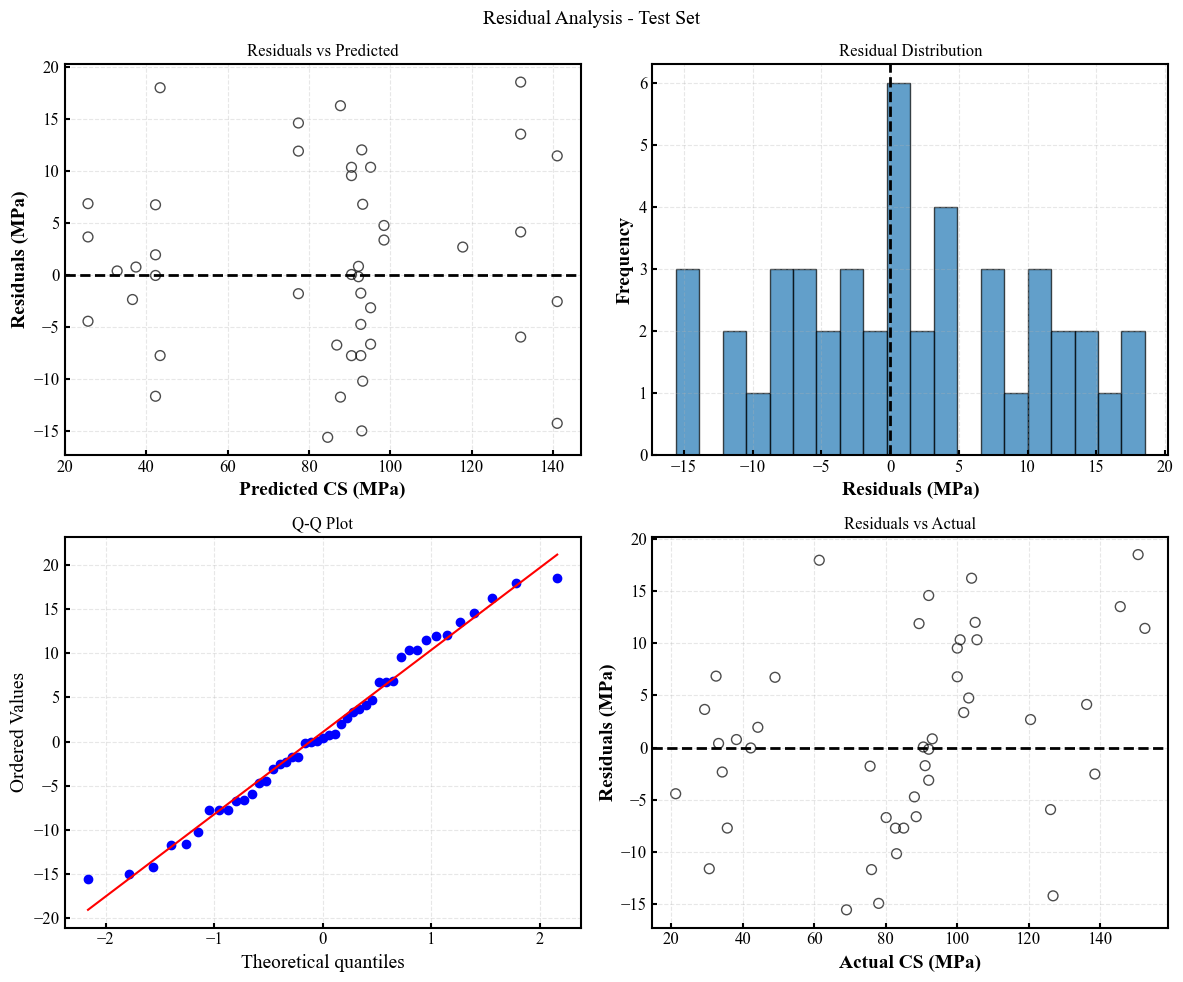

Generating learning curves...


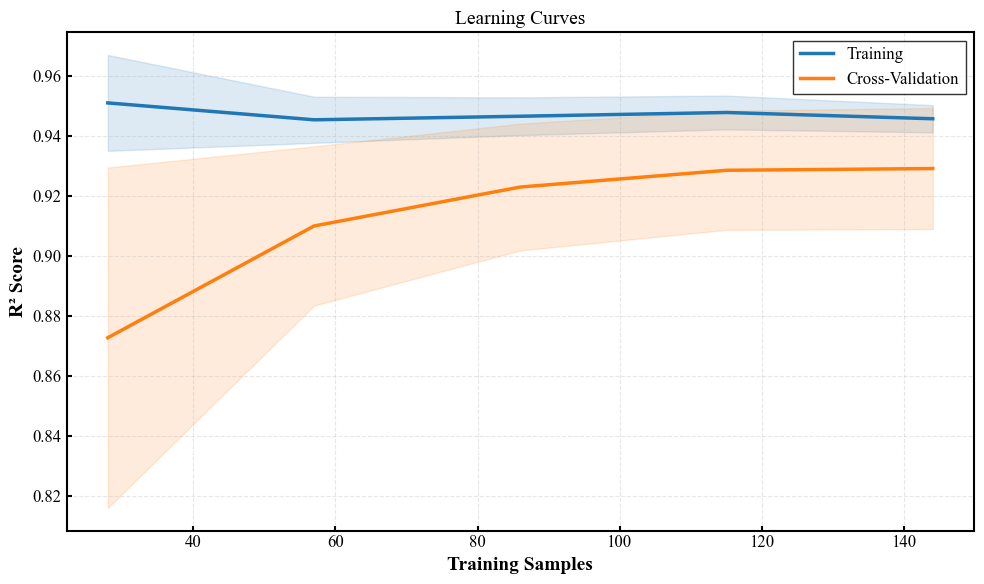

Calculating permutation importance...


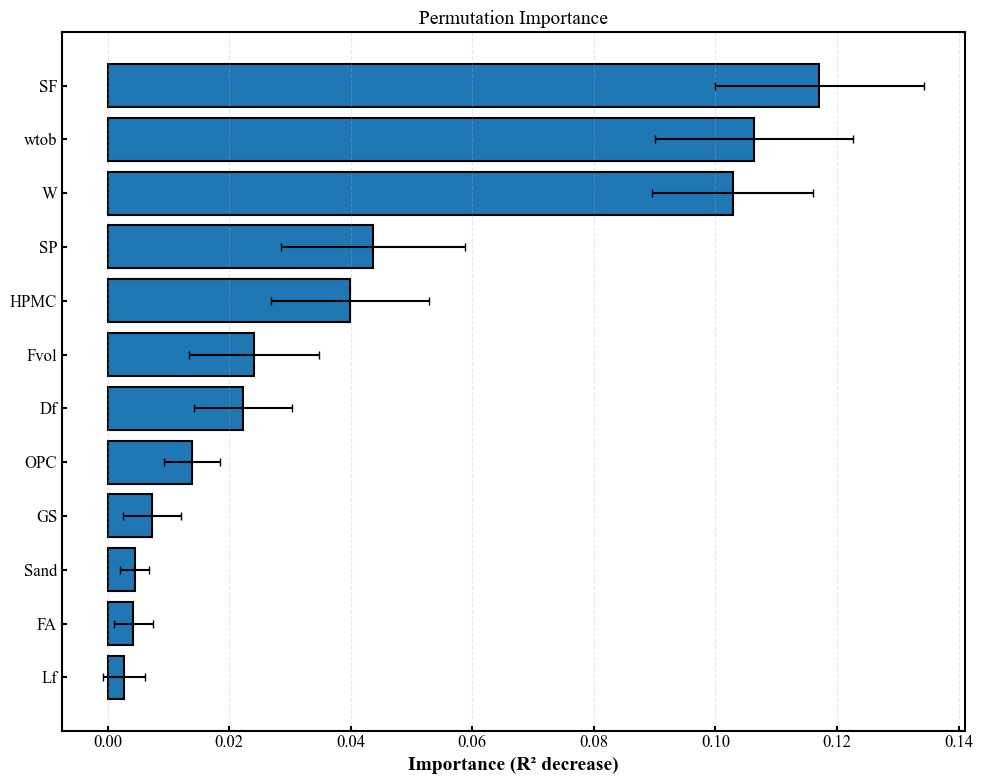

Performing SHAP analysis...


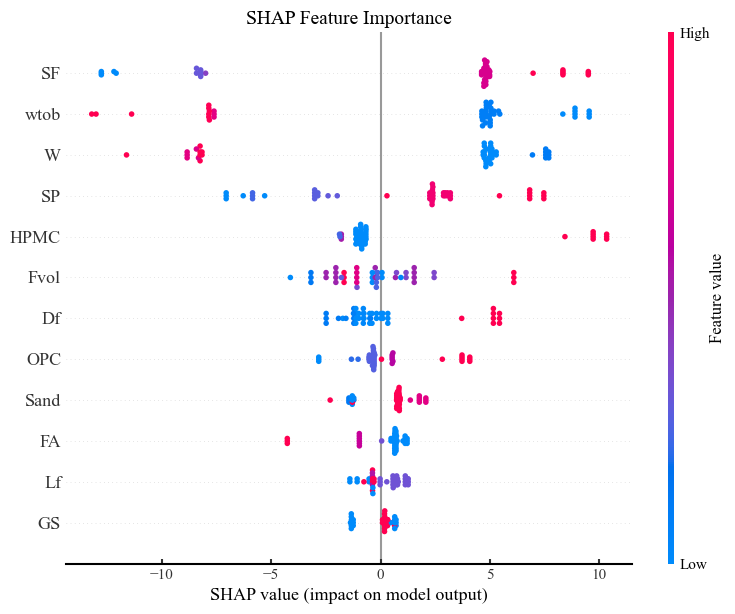

2026-08-14 15:59:40,663 - INFO - Available features for SHAP: ['OPC', 'Sand', 'wtob', 'FA', 'GS', 'SF', 'SP', 'HPMC', 'W', 'Fvol', 'Df', 'Lf']
2026-08-14 15:59:40,665 - INFO - No feature found for search term: water
2026-08-14 15:59:40,667 - INFO - No feature found for search term: w_b
2026-08-14 15:59:40,669 - INFO - No feature found for search term: silica
2026-08-14 15:59:40,670 - INFO - No feature found for search term: binder
2026-08-14 15:59:40,676 - INFO - SHAP values saved to: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost\SHAP\shap_values.joblib


Performing LIME analysis (supplementary local explanations)...


<Figure size 640x480 with 0 Axes>

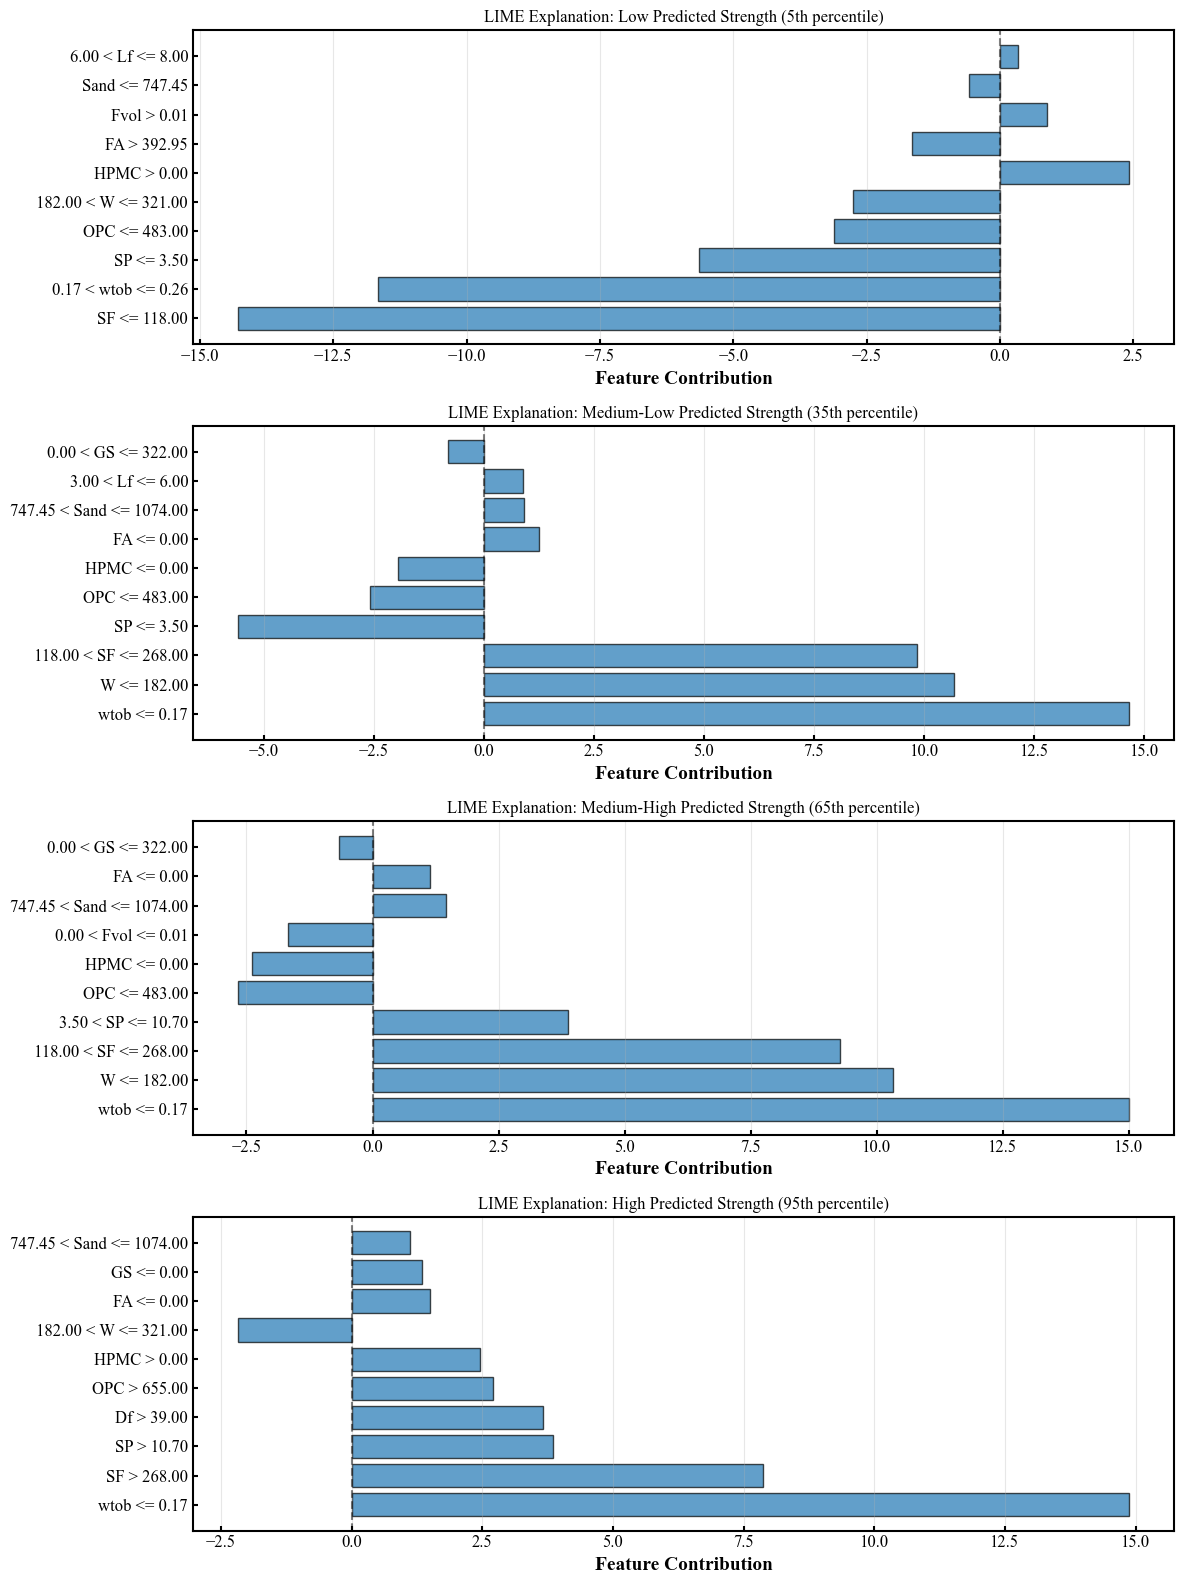


Saving results...

✓ All results saved to: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost


In [1]:
"""
CATBOOST REGRESSOR
CS (MPa) PREDICTION
VERSION 12.0
3D-PRINTED FIBER-REINFORCED CONCRETE

KEY METHODOLOGICAL FEATURES:
1. Fixed 80/20 train-test split
2. Randomized hyperparameter optimization using 5-fold K-fold CV
3. Repeated five-fold cross-validation, with five repetitions, for stability assessment
4. Leakage-free preprocessing within pipelines
5. SHAP-based model interpretation
6. Permutation importance for complementary feature-importance analysis
7. LIME as supplementary local interpretation
8. Bootstrap 95% confidence intervals for test-set performance metrics
9. Residual and learning-curve diagnostics
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    KFold,
    RepeatedKFold,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import joblib
import logging
import time
from pathlib import Path
import traceback
import re
from typing import Dict, Any, Union
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'stix'

# Optional imports
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False

try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False

# CatBoost import
try:
    from catboost import CatBoostRegressor, Pool
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("Warning: CatBoost not installed. Please install with: pip install catboost")

# ============================================================================
# LOGGING SETUP
# ============================================================================

def setup_logging(output_dir: Path):
    """Setup comprehensive logging."""
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)
    logger.handlers.clear()
    
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_format = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    console_handler.setFormatter(console_format)
    logger.addHandler(console_handler)
    
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / 'training.log'
    file_handler = logging.FileHandler(log_file, mode='w')
    file_handler.setLevel(logging.DEBUG)
    file_format = logging.Formatter('%(asctime)s - %(levelname)s - %(filename)s:%(lineno)d - %(message)s')
    file_handler.setFormatter(file_format)
    logger.addHandler(file_handler)
    
    return logger

logger = logging.getLogger(__name__)

# ============================================================================
# DATA PREPARATION
# ============================================================================

class DataPreparator:
    """Data loading and validation."""
    
    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.target_col = config.get('target_column')
        self.test_size = config.get('test_size', 0.20)
        self.random_state = config.get('random_state', 42)
        self.original_feature_names = None
        
    def load_and_validate(self, filepath: Union[str, Path]) -> tuple:
        """Load data with comprehensive validation."""
        logger.info(f"Loading data from: {filepath}")
        
        try:
            df = pd.read_csv(filepath, encoding='utf-8')
        except UnicodeDecodeError:
            df = pd.read_csv(filepath, encoding='ISO-8859-1')
        
        df.columns = df.columns.str.strip()
        logger.info(f"Initial data shape: {df.shape}")
        
        # Strict target column validation
        if self.target_col not in df.columns:
            raise ValueError(
                f"Target column '{self.target_col}' not found.\n"
                f"Available columns: {df.columns.tolist()}\n"
                f"Please specify the correct target column in config."
            )
        
        # Remove leakage columns
        for feature in self.config.get('leakage_columns', []):
            if feature in df.columns:
                df = df.drop(columns=[feature])
                logger.warning(f"REMOVED '{feature}' to prevent data leakage")
        
        X = df.drop(columns=[self.target_col])
        y = df[self.target_col]
        
        # Handle missing values in target
        nan_count = y.isna().sum()
        if nan_count > 0:
            logger.warning(f"Found {nan_count} NaN values in target")
            valid_idx = ~y.isna()
            X = X[valid_idx]
            y = y[valid_idx]
            logger.info(f"Removed {nan_count} rows. New shape: {X.shape}")
        
        # Handle infinite values
        if np.isinf(X.values).any():
            n_inf = np.isinf(X.values).sum()
            logger.warning(f"Found {n_inf} infinite values")
            X = X.replace([np.inf, -np.inf], np.nan)
        
        # Store original names before sanitization
        self.original_feature_names = X.columns.tolist()
        
        # Sanitize feature names
        X = self._sanitize_feature_names(X)
        
        logger.info(f"Loaded {len(X)} samples with {len(X.columns)} features")
        logger.info(f"Target: Min={y.min():.4f}, Max={y.max():.4f}, Mean={y.mean():.4f}")
        
        return X, y
    
    def _sanitize_feature_names(self, df: pd.DataFrame) -> pd.DataFrame:
        """Sanitize feature names for sklearn compatibility."""
        original_names = df.columns.tolist()
        sanitized = []
        
        for name in original_names:
            clean = re.sub(r'[()\[\]{}<>/\\|;:,.\'"]+', '_', str(name))
            clean = re.sub(r'\s+', '_', clean)
            clean = re.sub(r'[^a-zA-Z0-9_]', '', clean)
            if clean and clean[0].isdigit():
                clean = 'f_' + clean
            if not clean:
                clean = 'feature'
            
            if clean in sanitized:
                counter = 1
                while f"{clean}_{counter}" in sanitized:
                    counter += 1
                clean = f"{clean}_{counter}"
            sanitized.append(clean)
        
        df = df.copy()
        df.columns = sanitized
        df.attrs['original_feature_names'] = dict(zip(sanitized, original_names))
        return df

# ============================================================================
# HYPERPARAMETER OPTIMIZATION
# ============================================================================

class HyperparameterOptimizer:
    """Hyperparameter search using K-fold CV."""
    
    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.random_state = config.get('random_state', 42)
        self.n_trials = config.get('n_random_search_trials', 150)
        self.cv_folds = config.get('cv_folds', 5)
        self.search_n_jobs = config.get('search_n_jobs', -1)
        self.model_n_jobs = config.get('model_n_jobs', 1)
        self.random_search_results = None
        self.best_params = None
        
    def get_search_space(self) -> Dict:
        """Hyperparameter search space for CatBoost."""
        return {
            'model__iterations': [100, 200, 300, 500, 700, 1000],
            'model__depth': [3, 4, 5, 6, 7, 8, 10],
            'model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15],
            'model__l2_leaf_reg': [1, 2, 3, 4, 5, 7, 10],
            'model__border_count': [32, 64, 128, 255],
            'model__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        }
    
    def optimize(self, X_train, y_train):
        """Run RandomizedSearchCV with K-fold CV."""
        logger.info(f"Hyperparameter optimization: {self.n_trials} trials")
        logger.info(f"CV: {self.cv_folds}-fold KFold with shuffling")
        
        if not CATBOOST_AVAILABLE:
            raise ImportError("CatBoost is not available. Please install with: pip install catboost")
        
        # Simplified pipeline with standard SimpleImputer
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', CatBoostRegressor(
                random_seed=self.random_state,
                thread_count=self.model_n_jobs,
                verbose=False,
                loss_function='RMSE',
                eval_metric='RMSE'
            ))
        ])
        
        cv = KFold(
            n_splits=self.cv_folds,
            shuffle=True,
            random_state=self.random_state
        )
        
        random_search = RandomizedSearchCV(
            pipeline,
            self.get_search_space(),
            n_iter=self.n_trials,
            cv=cv,
            scoring='neg_mean_squared_error',
            n_jobs=self.search_n_jobs,
            random_state=self.random_state,
            verbose=0,
            return_train_score=False
        )
        
        start_time = time.time()
        random_search.fit(X_train, y_train)
        elapsed = time.time() - start_time
        
        self.random_search_results = random_search
        self.best_params = random_search.best_params_
        
        logger.info(f"Search completed in {elapsed:.1f} seconds")
        logger.info(f"Best CV score: {-random_search.best_score_:.4f}")
        
        return random_search, self.best_params
    
    def get_catboost_params(self) -> Dict:
        """Extract CatBoost parameters from best_params."""
        if self.best_params is None:
            raise ValueError("Must run optimize() first")
        
        cb_params = {}
        for key, value in self.best_params.items():
            clean_key = key.replace('model__', '')
            cb_params[clean_key] = value
        
        cb_params['random_seed'] = self.random_state
        cb_params['thread_count'] = self.model_n_jobs
        cb_params['verbose'] = False
        cb_params['loss_function'] = 'RMSE'
        cb_params['eval_metric'] = 'RMSE'
        
        return cb_params

# ============================================================================
# MODEL VALIDATION - STABILITY ASSESSMENT ONLY
# ============================================================================

class ModelValidator:
    """
    Model validation using Repeated KFold.
    
    IMPORTANT: This assesses stability of the optimized model on the training set.
    It is NOT an independent estimate of generalization performance.
    The independent test set remains the primary performance assessment.
    """
    
    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.cv_folds = config.get('cv_folds', 5)
        self.cv_repeats = config.get('cv_repeats', 5)
        self.random_state = config.get('random_state', 42)
        self.cv_repeat_predictions = None
        self.cv_fold_results = []
        self.cv_summary_stats = {}
        
    def evaluate_stability(self, X_train, y_train, cb_params):
        """
        Evaluate model stability using Repeated KFold.
        
        Returns: mean ± SD across 25 repeated validation folds.
        
        This is a POST-SELECTION stability analysis. The hyperparameters
        were already selected using a separate 5-fold CV. This repeated CV
        assesses how stable the selected model is across different data splits.
        """
        n_folds = self.cv_folds
        n_repeats = self.cv_repeats
        
        logger.info(f"Stability assessment: {n_folds} folds × {n_repeats} repeats")
        logger.info("NOTE: This assesses stability of the selected model, NOT independent generalization")
        
        cv = RepeatedKFold(
            n_splits=n_folds,
            n_repeats=n_repeats,
            random_state=self.random_state
        )
        
        n_samples = len(X_train)
        repeat_predictions = np.full((n_repeats, n_samples), np.nan)
        fold_results = []
        r2_scores = []
        rmse_scores = []
        mae_scores = []
        
        total_splits = n_folds * n_repeats
        fold_idx = 0
        
        iterator = cv.split(X_train)
        if TQDM_AVAILABLE:
            iterator = tqdm(iterator, desc="Stability", total=total_splits)
        
        for train_idx, val_idx in iterator:
            repeat = fold_idx // n_folds
            fold = fold_idx % n_folds
            
            X_train_fold = X_train.iloc[train_idx]
            y_train_fold = y_train.iloc[train_idx]
            X_val_fold = X_train.iloc[val_idx]
            y_val_fold = y_train.iloc[val_idx]
            
            # Simplified pipeline with standard SimpleImputer
            pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('model', CatBoostRegressor(**cb_params))
            ])
            pipeline.fit(X_train_fold, y_train_fold)
            
            y_pred_fold = pipeline.predict(X_val_fold)
            repeat_predictions[repeat, val_idx] = y_pred_fold
            
            fold_r2 = r2_score(y_val_fold, y_pred_fold)
            fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))
            fold_mae = mean_absolute_error(y_val_fold, y_pred_fold)
            
            r2_scores.append(fold_r2)
            rmse_scores.append(fold_rmse)
            mae_scores.append(fold_mae)
            
            fold_results.append({
                'repeat': repeat,
                'fold': fold,
                'R2': fold_r2,
                'RMSE': fold_rmse,
                'MAE': fold_mae,
                'n_train': len(train_idx),
                'n_val': len(val_idx)
            })
            fold_idx += 1
        
        self.cv_repeat_predictions = repeat_predictions
        self.cv_fold_results = fold_results
        
        self.cv_summary_stats = {
            'R2': {
                'mean': np.mean(r2_scores),
                'std': np.std(r2_scores, ddof=1),
                'min': np.min(r2_scores),
                'max': np.max(r2_scores)
            },
            'RMSE': {
                'mean': np.mean(rmse_scores),
                'std': np.std(rmse_scores, ddof=1),
                'min': np.min(rmse_scores),
                'max': np.max(rmse_scores)
            },
            'MAE': {
                'mean': np.mean(mae_scores),
                'std': np.std(mae_scores, ddof=1),
                'min': np.min(mae_scores),
                'max': np.max(mae_scores)
            }
        }
        
        logger.info(f"Stability R² (mean ± SD): {self.cv_summary_stats['R2']['mean']:.4f} ± {self.cv_summary_stats['R2']['std']:.4f}")
        
        return self.cv_summary_stats

# ============================================================================
# MODEL EVALUATION
# ============================================================================

class ModelEvaluator:
    """Model evaluation with comprehensive metrics and uncertainty."""
    
    def __init__(self, config: Dict[str, Any]):
        self.config = config
        self.n_bootstrap = config.get('n_bootstrap', 2000)
        self.random_state = config.get('random_state', 42)
        
    def evaluate_training(self, y_true, y_pred) -> Dict:
        """
        Evaluate training set performance.
        
        NOTE: Training metrics are diagnostic, NOT evidence of generalization.
        """
        metrics = {
            'R2': r2_score(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
        }
        
        # MAPE is supplementary - calculated after excluding zero values
        y_true_arr = np.array(y_true)
        mask = y_true_arr != 0
        if mask.any():
            metrics['MAPE'] = mean_absolute_percentage_error(
                y_true_arr[mask],
                np.array(y_pred)[mask]
            )
        
        return metrics
    
    def evaluate_test(self, y_true, y_pred) -> Dict:
        """
        Evaluate test set performance with comprehensive metrics.
        
        Primary metrics: R², RMSE, MAE
        Supplementary: NRMSE, correlations, relative-error percentages
        """
        y_true_arr = np.array(y_true)
        y_pred_arr = np.array(y_pred)
        errors = y_true_arr - y_pred_arr
        
        # Protect against zero denominators
        mean_y = np.mean(y_true_arr)
        range_y = np.max(y_true_arr) - np.min(y_true_arr)
        
        metrics = {
            # Primary metrics
            'R2': r2_score(y_true_arr, y_pred_arr),
            'RMSE': np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)),
            'MAE': mean_absolute_error(y_true_arr, y_pred_arr),
            
            # Supplementary metrics - with protection
            'NRMSE_mean': self._nrmse_safe(y_true_arr, y_pred_arr, 'mean', mean_y),
            'NRMSE_range': self._nrmse_safe(y_true_arr, y_pred_arr, 'range', range_y),
            'Pearson': pearsonr(y_true_arr, y_pred_arr)[0],
            'Spearman': spearmanr(y_true_arr, y_pred_arr)[0],
            'RelErr_10%': self._within_relative_error(y_true_arr, y_pred_arr, 0.10),
            'RelErr_20%': self._within_relative_error(y_true_arr, y_pred_arr, 0.20),
            'RelErr_30%': self._within_relative_error(y_true_arr, y_pred_arr, 0.30),
            
            'Error_Mean': np.mean(errors),
            'Error_Std': np.std(errors),
            'Error_Min': np.min(errors),
            'Error_Max': np.max(errors),
        }
        
        # MAPE is supplementary
        mask = y_true_arr != 0
        if mask.any():
            metrics['MAPE'] = mean_absolute_percentage_error(
                y_true_arr[mask],
                y_pred_arr[mask]
            )
        
        return metrics
    
    def bootstrap_ci(self, y_true, y_pred, n_bootstrap=None) -> Dict:
        """
        Bootstrap 95% confidence intervals for test-set performance metrics.
        
        These are bootstrap confidence intervals for the observed metrics,
        NOT prediction intervals.
        """
        n_bootstrap = n_bootstrap or self.n_bootstrap
        y_true_arr = np.array(y_true)
        y_pred_arr = np.array(y_pred)
        
        rng = np.random.default_rng(self.random_state)
        
        results = []
        iterator = range(n_bootstrap)
        if TQDM_AVAILABLE:
            iterator = tqdm(iterator, desc="Bootstrap", unit="samples")
        
        for _ in iterator:
            idx = rng.choice(
                len(y_true_arr),
                size=len(y_true_arr),
                replace=True
            )
            y_true_boot = y_true_arr[idx]
            y_pred_boot = y_pred_arr[idx]
            
            results.append({
                'R2': r2_score(y_true_boot, y_pred_boot),
                'RMSE': np.sqrt(mean_squared_error(y_true_boot, y_pred_boot)),
                'MAE': mean_absolute_error(y_true_boot, y_pred_boot),
            })
        
        # Aggregate
        ci = {}
        for metric in ['R2', 'RMSE', 'MAE']:
            values = [r[metric] for r in results if not np.isnan(r[metric])]
            if values:
                ci[metric] = {
                    'mean': np.mean(values),
                    'std': np.std(values),
                    'lower_95': np.percentile(values, 2.5),
                    'upper_95': np.percentile(values, 97.5),
                    'n': len(values)
                }
        
        return ci
    
    def _nrmse_safe(self, y_true, y_pred, method, denominator):
        """Safe NRMSE calculation with denominator protection."""
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        if abs(denominator) < 1e-10:
            return np.nan
        if method == 'mean':
            return rmse / denominator
        elif method == 'range':
            return rmse / denominator
        else:
            return rmse / np.std(y_true)
    
    def _within_relative_error(self, y_true, y_pred, tolerance):
        """Percentage of predictions within relative error tolerance."""
        mask = y_true != 0
        if mask.sum() == 0:
            return 0.0
        relative_errors = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
        return np.mean(relative_errors <= tolerance) * 100

# ============================================================================
# PLOTTING FUNCTIONS - HIGH CONTRAST, DPI 600
# ============================================================================

def setup_plot_style():
    """Set up consistent plotting style with high contrast."""
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    # High contrast settings
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['xtick.color'] = 'black'
    plt.rcParams['ytick.color'] = 'black'
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['xtick.major.width'] = 1.5
    plt.rcParams['ytick.major.width'] = 1.5

def plot_actual_vs_predicted(y_true, y_pred, title, save_path=None, dpi=600, 
                             error_lines=None, error_labels=None):
    """Plot actual vs predicted with optional error lines."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Determine axis limits
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    padding = (max_val - min_val) * 0.05
    min_val -= padding
    max_val += padding
    
    # Scatter points - high contrast
    ax.scatter(y_true, y_pred, alpha=0.7, s=60, 
               facecolors='none', edgecolors='black', linewidths=1.5)
    
    # Perfect prediction line
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k-', linewidth=2.5, label='Perfect Prediction')
    
    # Error lines (e.g., ±20%, ±30%)
    if error_lines is not None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High contrast colors
        for i, (error, label) in enumerate(zip(error_lines, error_labels)):
            color = colors[i % len(colors)]
            ax.plot([min_val, max_val], 
                    [min_val * (1 + error), max_val * (1 + error)], 
                    '--', color=color, linewidth=1.5, alpha=0.7,
                    label=f'{label}')
            ax.plot([min_val, max_val], 
                    [min_val * (1 - error), max_val * (1 - error)], 
                    '--', color=color, linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Actual CS (MPa)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted CS (MPa)', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', frameon=True, edgecolor='black', fancybox=False)
    
    # Black border
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig

def plot_residuals(y_true, y_pred, title, save_path=None, dpi=600):
    """Plot residual analysis with high contrast."""
    setup_plot_style()
    
    residuals = np.array(y_true) - np.array(y_pred)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Residuals vs Predicted
    ax1 = axes[0, 0]
    ax1.scatter(y_pred, residuals, alpha=0.7, s=50,
                facecolors='none', edgecolors='black', linewidths=1)
    ax1.axhline(y=0, color='k', linestyle='--', linewidth=2)
    ax1.set_xlabel('Predicted CS (MPa)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Residuals (MPa)', fontsize=14, fontweight='bold')
    ax1.set_title('Residuals vs Predicted', fontsize=12)
    ax1.grid(True, alpha=0.3, linestyle='--')
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    # Histogram of residuals
    ax2 = axes[0, 1]
    ax2.hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='#1f77b4')
    ax2.axvline(x=0, color='k', linestyle='--', linewidth=2)
    ax2.set_xlabel('Residuals (MPa)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax2.set_title('Residual Distribution', fontsize=12)
    ax2.grid(True, alpha=0.3, linestyle='--')
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    # Q-Q plot
    ax3 = axes[1, 0]
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot', fontsize=12)
    ax3.grid(True, alpha=0.3, linestyle='--')
    for spine in ax3.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    # Residuals vs Actual
    ax4 = axes[1, 1]
    ax4.scatter(y_true, residuals, alpha=0.7, s=50,
                facecolors='none', edgecolors='black', linewidths=1)
    ax4.axhline(y=0, color='k', linestyle='--', linewidth=2)
    ax4.set_xlabel('Actual CS (MPa)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Residuals (MPa)', fontsize=14, fontweight='bold')
    ax4.set_title('Residuals vs Actual', fontsize=12)
    ax4.grid(True, alpha=0.3, linestyle='--')
    for spine in ax4.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig

def plot_learning_curves(learning_curves, save_path=None, dpi=600):
    """Plot learning curves with high contrast."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    train_sizes = learning_curves['train_sizes']
    train_mean = learning_curves['train_scores_mean']
    train_std = learning_curves['train_scores_std']
    test_mean = learning_curves['test_scores_mean']
    test_std = learning_curves['test_scores_std']
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#1f77b4')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                    alpha=0.15, color='#ff7f0e')
    
    ax.plot(train_sizes, train_mean, '-', linewidth=2.5, color='#1f77b4', label='Training')
    ax.plot(train_sizes, test_mean, '-', linewidth=2.5, color='#ff7f0e', label='Cross-Validation')
    
    ax.set_xlabel('Training Samples', fontsize=14, fontweight='bold')
    ax.set_ylabel('R² Score', fontsize=14, fontweight='bold')
    ax.set_title('Learning Curves', fontsize=14)
    ax.legend(frameon=True, edgecolor='black', fancybox=False)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig

def plot_permutation_importance(importance_df, save_path=None, dpi=600):
    """Plot permutation importance with high contrast."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    top_n = min(15, len(importance_df))
    top_df = importance_df.tail(top_n)
    
    ax.barh(top_df['Feature'], top_df['Importance'], 
            xerr=top_df['Std'] if 'Std' in top_df.columns else None,
            color='#1f77b4', edgecolor='black', linewidth=1.5,
            capsize=3)
    ax.set_xlabel('Importance (R² decrease)', fontsize=14, fontweight='bold')
    ax.set_title('Permutation Importance', fontsize=14)
    ax.grid(True, alpha=0.3, linestyle='--', axis='x')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig

# ============================================================================
# SHAP INTERPRETATION
# ============================================================================

class SHAPInterpreter:
    """
    SHAP for model interpretation.
    
    SHAP dependence plots show how feature values relate to their contributions
    to the model prediction. They help identify nonlinear and non-monotonic
    model behavior.
    """
    
    def __init__(self, model, X_transformed, feature_names, feature_mapping, output_dir):
        self.model = model
        self.X_transformed = np.asarray(X_transformed)
        self.feature_names = feature_names
        self.feature_mapping = feature_mapping  # sanitized -> original
        self.output_dir = Path(output_dir)
        self.explainer = None
        self.shap_values = None
        self.expected_value = None
        self.mean_abs_shap = None
        
        # Create reverse mapping for original -> sanitized lookup
        self.reverse_mapping = {v: k for k, v in feature_mapping.items()}
        
        # Ensure SHAP directory exists
        (self.output_dir / 'SHAP').mkdir(parents=True, exist_ok=True)
        
    def fit(self):
        """Initialize SHAP explainer."""
        if not SHAP_AVAILABLE:
            logger.warning("SHAP not available")
            return None
        
        try:
            self.explainer = shap.TreeExplainer(self.model)
            self.shap_values = self.explainer.shap_values(self.X_transformed)
            self.expected_value = self.explainer.expected_value
            
            # Calculate mean absolute SHAP values for importance
            if len(self.shap_values.shape) == 1:
                self.mean_abs_shap = np.abs(self.shap_values)
            else:
                self.mean_abs_shap = np.mean(np.abs(self.shap_values), axis=0)
            
            # Save SHAP importance values
            shap_importance_df = pd.DataFrame({
                'Feature': self.feature_names,
                'Mean_ABS_SHAP': self.mean_abs_shap
            }).sort_values('Mean_ABS_SHAP', ascending=False)
            
            shap_importance_df.to_csv(
                self.output_dir / 'Tables' / 'shap_importance.csv',
                index=False
            )
            
            return self
        except Exception as e:
            logger.warning(f"SHAP failed: {e}")
            return None
    
    def plot_summary(self, save=True, dpi=600):
        """SHAP summary plot."""
        if self.shap_values is None:
            return None
        
        try:
            setup_plot_style()
            shap.summary_plot(
                self.shap_values,
                self.X_transformed,
                feature_names=self.feature_names,
                show=False,
                max_display=15
            )
            plt.title('SHAP Feature Importance', fontsize=14)
            plt.tight_layout()
            
            if save:
                save_path = self.output_dir / 'Plots' / 'shap_summary.png'
                plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
            plt.show()
            return plt.gcf()
        except Exception as e:
            logger.warning(f"SHAP summary plot failed: {e}")
            return None
    
    def get_sanitized_name(self, original_name: str) -> str:
        """Get sanitized feature name from original name."""
        # First check if it's already sanitized
        if original_name in self.feature_names:
            return original_name
        
        # Check reverse mapping
        if original_name in self.reverse_mapping:
            return self.reverse_mapping[original_name]
        
        # Try case-insensitive match
        for sanitized, original in self.feature_mapping.items():
            if original.lower() == original_name.lower():
                return sanitized
        
        # Try partial match
        for sanitized, original in self.feature_mapping.items():
            if original_name.lower() in original.lower() or original.lower() in original_name.lower():
                logger.info(f"Found partial match: '{original_name}' -> '{original}'")
                return sanitized
        
        logger.warning(f"Feature '{original_name}' not found. Available: {list(self.feature_mapping.keys())}")
        return None
    
    def plot_dependence(self, feature_name: str, save=True, dpi=600):
        """
        SHAP dependence plot.
        
        Shows how feature values relate to their contributions to the model
        prediction. Helps identify nonlinear and non-monotonic behavior.
        """
        if self.shap_values is None:
            return None
        
        sanitized_name = self.get_sanitized_name(feature_name)
        if sanitized_name is None:
            return None
        
        try:
            feature_idx = self.feature_names.index(sanitized_name)
            
            setup_plot_style()
            shap.dependence_plot(
                feature_idx,
                self.shap_values,
                self.X_transformed,
                feature_names=self.feature_names,
                show=False
            )
            original_name = self.feature_mapping.get(sanitized_name, sanitized_name)
            plt.title(f'SHAP Dependence: {original_name}', fontsize=14)
            plt.tight_layout()
            
            if save:
                save_path = self.output_dir / 'Plots' / f'shap_dependence_{sanitized_name}.png'
                plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
            plt.show()
            return plt.gcf()
        except Exception as e:
            logger.warning(f"SHAP dependence plot failed for {feature_name}: {e}")
            return None
    
    def plot_interaction(self, feature1: str, feature2: str, save=True, dpi=600):
        """
        SHAP dependence plot with interaction coloring.
        """
        if self.shap_values is None:
            return None
        
        sanitized1 = self.get_sanitized_name(feature1)
        sanitized2 = self.get_sanitized_name(feature2)
        
        if sanitized1 is None or sanitized2 is None:
            return None
        
        try:
            idx1 = self.feature_names.index(sanitized1)
            idx2 = self.feature_names.index(sanitized2)
            
            setup_plot_style()
            shap.dependence_plot(
                idx1,
                self.shap_values,
                self.X_transformed,
                feature_names=self.feature_names,
                show=False,
                interaction_index=idx2
            )
            original1 = self.feature_mapping.get(sanitized1, sanitized1)
            original2 = self.feature_mapping.get(sanitized2, sanitized2)
            plt.title(f'SHAP Dependence: {original1}\n(color by {original2})', fontsize=14)
            plt.tight_layout()
            
            if save:
                save_path = self.output_dir / 'Plots' / f'shap_interaction_{sanitized1}_{sanitized2}.png'
                plt.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
            plt.show()
            return plt.gcf()
        except Exception as e:
            logger.warning(f"SHAP interaction plot failed: {e}")
            return None

# ============================================================================
# LIME - SUPPLEMENTARY LOCAL EXPLANATIONS
# ============================================================================

class LIMEInterpreter:
    """LIME for supplementary local explanations."""
    
    def __init__(self, model, X_train_transformed, X_test_transformed, feature_names, output_dir):
        self.model = model
        self.X_train_transformed = np.asarray(X_train_transformed)
        self.X_test_transformed = np.asarray(X_test_transformed)
        self.feature_names = feature_names
        self.output_dir = Path(output_dir)
        self.explainer = None
        
    def fit(self):
        """Initialize LIME explainer."""
        if not LIME_AVAILABLE:
            logger.warning("LIME not available")
            return None
        
        try:
            self.explainer = LimeTabularExplainer(
                self.X_train_transformed,
                feature_names=self.feature_names,
                mode='regression',
                random_state=42,
                verbose=False
            )
            return self
        except Exception as e:
            logger.warning(f"LIME failed: {e}")
            return None
    
    def explain_sample(self, sample_idx: int, num_features: int = 10):
        """Explain a single sample using LIME."""
        if self.explainer is None:
            return None
        
        try:
            sample = self.X_test_transformed[sample_idx]
            exp = self.explainer.explain_instance(
                sample,
                self.model.predict,
                num_features=num_features,
                num_samples=5000
            )
            return exp
        except Exception as e:
            logger.warning(f"LIME explanation failed: {e}")
            return None

# ============================================================================
# MAIN PIPELINE
# ============================================================================

def main():
    """Main execution."""
    print("\n" + "=" * 80)
    print("CATBOOST REGRESSOR - CS (MPa) PREDICTION")
    print("3D-PRINTED FIBER-REINFORCED CONCRETE")
    print("=" * 80)
    
    print("\nMETHODOLOGY:")
    print("  - Hyperparameter optimization: RandomizedSearchCV with 5-fold KFold")
    print("  - Stability assessment: Repeated five-fold CV (5 repeats)")
    print("  - Primary interpretation: SHAP")
    print("  - Complementary importance: Permutation importance")
    print("  - Supplementary local: LIME")
    print("=" * 80 + "\n")
    
    try:
        # ================================================================
        # CONFIGURATION
        # ================================================================
        
        config = {
            'results_dir': r"D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost",
            'target_column': 'CS (MPa)',
            'test_size': 0.20,
            'random_state': 42,
            'cv_folds': 5,
            'cv_repeats': 5,
            'n_random_search_trials': 150,
            'search_n_jobs': -1,
            'model_n_jobs': 1,
            'n_bootstrap': 2000,
            'n_permutation_repeats': 10,
            'use_learning_curves': True,
        }
        
        results_dir = Path(config['results_dir'])
        
        # Create all necessary directories
        for folder in ['Plots', 'Models', 'Results', 'Tables', 'Logs', 'SHAP']:
            (results_dir / folder).mkdir(parents=True, exist_ok=True)
        
        setup_logging(results_dir / 'Logs')
        
        # ================================================================
        # DATA PREPARATION
        # ================================================================
        
        preparator = DataPreparator(config)
        data_path = r"D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Data\Data.csv"
        X, y = preparator.load_and_validate(data_path)
        
        # Store original feature names and mapping
        original_feature_names = preparator.original_feature_names
        feature_name_mapping = dict(zip(X.columns, original_feature_names))
        
        # Print available features
        logger.info(f"Available features: {X.columns.tolist()}")
        print(f"\nAvailable features: {X.columns.tolist()}")
        
        # Train-test split with tracking
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=config['test_size'],
            random_state=config['random_state'],
            shuffle=True
        )
        
        # Save train and test indices for reproducibility
        train_indices = X_train.index.tolist()
        test_indices = X_test.index.tolist()
        
        print(f"\nSplit completed:")
        print(f"  Training: {len(X_train)} samples")
        print(f"  Test: {len(X_test)} samples")
        print(f"  Features: {X_train.columns.tolist()}")
        
        # ================================================================
        # HYPERPARAMETER OPTIMIZATION
        # ================================================================
        
        optimizer = HyperparameterOptimizer(config)
        random_search, best_params = optimizer.optimize(X_train, y_train)
        cb_params = optimizer.get_catboost_params()
        
        print(f"\nBest hyperparameters:")
        for key, value in cb_params.items():
            print(f"  {key}: {value}")
        
        # Save RandomizedSearchCV results
        search_results_df = pd.DataFrame(random_search.cv_results_)
        search_results_df.to_csv(
            results_dir / 'Tables' / 'random_search_results.csv',
            index=False
        )
        
        # ================================================================
        # STABILITY ASSESSMENT - POST-SELECTION
        # ================================================================
        
        validator = ModelValidator(config)
        cv_summary = validator.evaluate_stability(X_train, y_train, cb_params)
        
        print(f"\nStability assessment (mean ± SD across 25 repeated validation folds):")
        print(f"  R²: {cv_summary['R2']['mean']:.4f} ± {cv_summary['R2']['std']:.4f}")
        print(f"  RMSE: {cv_summary['RMSE']['mean']:.4f} ± {cv_summary['RMSE']['std']:.4f} MPa")
        print(f"  MAE: {cv_summary['MAE']['mean']:.4f} ± {cv_summary['MAE']['std']:.4f} MPa")
        
        # Save CV fold results
        cv_fold_df = pd.DataFrame(validator.cv_fold_results)
        cv_fold_df.to_csv(
            results_dir / 'Tables' / 'cv_fold_results.csv',
            index=False
        )
        
        # ================================================================
        # FINAL MODEL TRAINING
        # ================================================================
        
        print("\nTraining final model...")
        
        final_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', CatBoostRegressor(**cb_params))
        ])
        final_pipeline.fit(X_train, y_train)
        
        # ================================================================
        # TRAINING EVALUATION (DIAGNOSTIC)
        # ================================================================
        
        evaluator = ModelEvaluator(config)
        y_train_pred = final_pipeline.predict(X_train)
        train_metrics = evaluator.evaluate_training(y_train, y_train_pred)
        
        print(f"\nTraining performance (diagnostic - NOT generalization):")
        print(f"  R²: {train_metrics['R2']:.4f}")
        print(f"  RMSE: {train_metrics['RMSE']:.4f} MPa")
        print(f"  MAE: {train_metrics['MAE']:.4f} MPa")
        
        # ================================================================
        # TEST EVALUATION (PRIMARY GENERALIZATION)
        # ================================================================
        
        print(f"\nTest set evaluation (primary generalization):")
        y_test_pred = final_pipeline.predict(X_test)
        test_metrics = evaluator.evaluate_test(y_test, y_test_pred)
        
        print(f"  R²: {test_metrics['R2']:.4f}")
        print(f"  RMSE: {test_metrics['RMSE']:.4f} MPa")
        print(f"  MAE: {test_metrics['MAE']:.4f} MPa")
        print(f"  Predictions within ±10% relative error: {test_metrics['RelErr_10%']:.2f}%")
        
        # ================================================================
        # BOOTSTRAP CONFIDENCE INTERVALS
        # ================================================================
        
        bootstrap_ci = evaluator.bootstrap_ci(y_test, y_test_pred)
        
        print(f"\nBootstrap 95% confidence intervals for test-set performance metrics:")
        for metric in ['R2', 'RMSE', 'MAE']:
            if metric in bootstrap_ci:
                ci = bootstrap_ci[metric]
                print(f"  {metric}: {ci['mean']:.4f} [{ci['lower_95']:.4f}, {ci['upper_95']:.4f}]")
        
        # ================================================================
        # PLOTS - PUBLICATION QUALITY, HIGH CONTRAST, DPI 600
        # ================================================================
        
        print("\nGenerating plots...")
        
        # Actual vs Predicted - Training with error lines
        plot_actual_vs_predicted(
            y_train, y_train_pred,
            f'Training Set (Diagnostic)\nR² = {train_metrics["R2"]:.4f}, RMSE = {train_metrics["RMSE"]:.4f} MPa',
            save_path=results_dir / 'Plots' / 'actual_vs_predicted_training.png',
            error_lines=[0.20, 0.30],
            error_labels=['±20%', '±30%']
        )
        
        # Actual vs Predicted - Test with error lines
        plot_actual_vs_predicted(
            y_test, y_test_pred,
            f'Test Set (Primary Generalization)\nR² = {test_metrics["R2"]:.4f}, RMSE = {test_metrics["RMSE"]:.4f} MPa',
            save_path=results_dir / 'Plots' / 'actual_vs_predicted_test.png',
            error_lines=[0.20, 0.30],
            error_labels=['±20%', '±30%']
        )
        
        # Residuals - Test
        plot_residuals(
            y_test, y_test_pred,
            'Residual Analysis - Test Set',
            save_path=results_dir / 'Plots' / 'residuals_test.png'
        )
        
        # ================================================================
        # LEARNING CURVES
        # ================================================================
        
        print("Generating learning curves...")
        
        lc_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', CatBoostRegressor(**cb_params))
        ])
        
        cv = KFold(
            n_splits=config['cv_folds'],
            shuffle=True,
            random_state=config['random_state']
        )
        
        train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
        
        train_sizes_abs, train_scores, test_scores = learning_curve(
            lc_pipeline,
            X_train, y_train,
            cv=cv,
            train_sizes=train_sizes,
            scoring='r2',
            n_jobs=config.get('search_n_jobs', -1),
            shuffle=True,
            random_state=config['random_state']
        )
        
        learning_curves = {
            'train_sizes': train_sizes_abs,
            'train_scores_mean': np.mean(train_scores, axis=1),
            'train_scores_std': np.std(train_scores, axis=1),
            'test_scores_mean': np.mean(test_scores, axis=1),
            'test_scores_std': np.std(test_scores, axis=1)
        }
        
        plot_learning_curves(
            learning_curves,
            save_path=results_dir / 'Plots' / 'learning_curves.png'
        )
        
        # ================================================================
        # PERMUTATION IMPORTANCE
        # ================================================================
        
        print("Calculating permutation importance...")
        
        perm_importance = permutation_importance(
            final_pipeline, X_test, y_test,
            n_repeats=config['n_permutation_repeats'],
            random_state=config['random_state'],
            scoring='r2',
            n_jobs=config.get('search_n_jobs', -1)
        )
        
        imp_df = pd.DataFrame({
            'Feature': X_train.columns,
            'Importance': perm_importance.importances_mean,
            'Std': perm_importance.importances_std
        }).sort_values('Importance', ascending=True)
        
        # Save permutation importance
        imp_df.to_csv(
            results_dir / 'Tables' / 'permutation_importance.csv',
            index=False
        )
        
        plot_permutation_importance(
            imp_df,
            save_path=results_dir / 'Plots' / 'permutation_importance.png'
        )
        
        # ================================================================
        # SHAP ANALYSIS - PRIMARY INTERPRETATION
        # ================================================================
        
        if SHAP_AVAILABLE:
            print("Performing SHAP analysis...")
            
            X_test_transformed = final_pipeline.named_steps['imputer'].transform(X_test)
            X_test_transformed = np.asarray(X_test_transformed)
            cb_model = final_pipeline.named_steps['model']
            feature_names = X_train.columns.tolist()
            
            shap_interpreter = SHAPInterpreter(
                cb_model,
                X_test_transformed,
                feature_names,
                feature_name_mapping,
                results_dir
            )
            shap_interpreter.fit()
            
            # SHAP summary plot
            shap_interpreter.plot_summary()
            
            # Get actual feature names
            available_features = feature_names
            logger.info(f"Available features for SHAP: {available_features}")
            
            # Find features containing key terms - validate before plotting
            feature_groups = {
                'water': ['Water Content', 'Water'],
                'w_b': ['Water-to-Binder Ratio', 'W/B'],
                'silica': ['Silica Fume Content', 'Silica Fume'],
                'binder': ['Binder Content', 'Binder', 'Cement']
            }
            
            plotted_features = []
            for search_term, display_names in feature_groups.items():
                matched = [f for f in available_features if search_term in f.lower()]
                if matched:
                    for f in matched[:1]:
                        logger.info(f"Plotting SHAP dependence for: {f}")
                        shap_interpreter.plot_dependence(f)
                        plotted_features.append(f)
                else:
                    logger.info(f"No feature found for search term: {search_term}")
            
            # SHAP interaction plots for available features
            water_features = [f for f in available_features if 'water' in f.lower()]
            silica_features = [f for f in available_features if 'silica' in f.lower() or 'sf' in f.lower()]
            wb_features = [f for f in available_features if 'w_b' in f.lower() or 'wb' in f.lower()]
            
            if water_features and silica_features:
                logger.info(f"Plotting SHAP interaction: {water_features[0]} × {silica_features[0]}")
                shap_interpreter.plot_interaction(water_features[0], silica_features[0])
            if water_features and wb_features:
                logger.info(f"Plotting SHAP interaction: {water_features[0]} × {wb_features[0]}")
                shap_interpreter.plot_interaction(water_features[0], wb_features[0])
            
            # Save SHAP values
            if shap_interpreter.shap_values is not None:
                shap_data = {
                    'shap_values': shap_interpreter.shap_values,
                    'expected_value': shap_interpreter.expected_value,
                    'feature_names': feature_names,
                    'mean_abs_shap': shap_interpreter.mean_abs_shap
                }
                shap_path = results_dir / 'SHAP' / 'shap_values.joblib'
                joblib.dump(shap_data, shap_path)
                logger.info(f"SHAP values saved to: {shap_path}")
        
        # ================================================================
        # LIME - SUPPLEMENTARY LOCAL EXPLANATIONS
        # ================================================================
        
        if LIME_AVAILABLE:
            print("Performing LIME analysis (supplementary local explanations)...")
            
            X_train_transformed = final_pipeline.named_steps['imputer'].transform(X_train)
            X_train_transformed = np.asarray(X_train_transformed)
            X_test_transformed = final_pipeline.named_steps['imputer'].transform(X_test)
            X_test_transformed = np.asarray(X_test_transformed)
            cb_model = final_pipeline.named_steps['model']
            feature_names = X_train.columns.tolist()
            
            lime_interpreter = LIMEInterpreter(
                cb_model,
                X_train_transformed,
                X_test_transformed,
                feature_names,
                results_dir
            )
            lime_interpreter.fit()
            
            # Explain representative samples based on predicted strength
            y_pred_test = cb_model.predict(X_test_transformed)
            sorted_idx = np.argsort(y_pred_test)
            n_test = len(y_pred_test)
            
            representative_idx = [
                sorted_idx[int(n_test * 0.05)],
                sorted_idx[int(n_test * 0.35)],
                sorted_idx[int(n_test * 0.65)],
                sorted_idx[int(n_test * 0.95)]
            ]
            
            # Labels based on predicted strength quantiles
            labels = [
                'Low Predicted Strength (5th percentile)',
                'Medium-Low Predicted Strength (35th percentile)',
                'Medium-High Predicted Strength (65th percentile)',
                'High Predicted Strength (95th percentile)'
            ]
            
            explanations = []
            for idx in representative_idx:
                exp = lime_interpreter.explain_sample(idx)
                if exp is not None:
                    explanations.append(exp)
            
            # Plot LIME explanations if available
            if explanations:
                fig, axes = plt.subplots(len(explanations), 1, figsize=(12, 4 * len(explanations)))
                if len(explanations) == 1:
                    axes = [axes]
                
                setup_plot_style()
                
                for i, exp in enumerate(explanations):
                    if i < len(axes):
                        ax = axes[i]
                        contributions = exp.as_list()
                        features, weights = zip(*contributions) if contributions else ([], [])
                        
                        y_pos = np.arange(len(features))
                        ax.barh(y_pos, weights, alpha=0.7, color='#1f77b4', edgecolor='black', linewidth=1)
                        ax.set_yticks(y_pos)
                        ax.set_yticklabels(features)
                        ax.set_xlabel('Feature Contribution', fontsize=14, fontweight='bold')
                        ax.set_title(f"LIME Explanation: {labels[i] if i < len(labels) else f'Sample {i}'}", fontsize=12)
                        ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
                        ax.grid(True, alpha=0.3, axis='x')
                        
                        for spine in ax.spines.values():
                            spine.set_edgecolor('black')
                            spine.set_linewidth(1.5)
                
                plt.tight_layout()
                plt.savefig(results_dir / 'Plots' / 'lime_explanations.png', dpi=600, bbox_inches='tight', facecolor='white')
                plt.show()
        
        # ================================================================
        # SAVE RESULTS
        # ================================================================
        
        print(f"\nSaving results...")
        
        # Calculate best CV metrics
        best_cv_mse = -random_search.best_score_
        best_cv_rmse = np.sqrt(best_cv_mse)
        
        results = {
            'best_params': cb_params,
            'best_cv_mse': best_cv_mse,
            'best_cv_rmse': best_cv_rmse,
            'train_metrics': train_metrics,
            'test_metrics': test_metrics,
            'cv_summary': cv_summary,
            'bootstrap_ci': bootstrap_ci,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': len(X_train.columns),
            'cv_folds': config['cv_folds'],
            'cv_repeats': config['cv_repeats'],
            'random_search_trials': config['n_random_search_trials'],
            'feature_names': X_train.columns.tolist(),
            'original_feature_names': original_feature_names,
            'feature_name_mapping': feature_name_mapping,
            'train_indices': train_indices,
            'test_indices': test_indices,
            'random_state': config['random_state'],
            'model_type': 'CatBoost',
        }
        
        # Save model
        joblib.dump(final_pipeline, results_dir / 'Models' / 'final_model.joblib')
        joblib.dump(results, results_dir / 'Results' / 'results.joblib')
        
        # Save test metrics as CSV
        metrics_df = pd.DataFrame([
            {'Metric': k, 'Value': v} for k, v in test_metrics.items()
            if not isinstance(v, (dict, list, np.ndarray))
        ])
        metrics_df.to_csv(results_dir / 'Tables' / 'test_metrics.csv', index=False)
        
        # Save training metrics (diagnostic)
        train_df = pd.DataFrame([
            {'Metric': k, 'Value': v} for k, v in train_metrics.items()
            if not isinstance(v, (dict, list, np.ndarray))
        ])
        train_df.to_csv(results_dir / 'Tables' / 'training_metrics.csv', index=False)
        
        # Save CV summary
        cv_data = []
        for metric, stats in cv_summary.items():
            for stat, value in stats.items():
                cv_data.append({'Metric': f"{metric}_{stat}", 'Value': value})
        cv_df = pd.DataFrame(cv_data)
        cv_df.to_csv(results_dir / 'Tables' / 'cv_summary.csv', index=False)
        
        # Save test predictions with index
        pred_df = pd.DataFrame({
            'Sample_ID': y_test.index,
            'Actual_CS': y_test.values,
            'Predicted_CS': y_test_pred,
            'Residual': y_test.values - y_test_pred,
            'Relative_Error_%': ((y_test.values - y_test_pred) / y_test.values * 100)
        })
        pred_df.to_csv(results_dir / 'Tables' / 'test_predictions.csv', index=False)
        
        # Save CatBoost feature importance
        try:
            feature_importance = cb_model.get_feature_importance()
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': feature_importance
            }).sort_values('Importance', ascending=False)
            importance_df.to_csv(results_dir / 'Tables' / 'catboost_feature_importance.csv', index=False)
        except:
            pass
        
        print(f"\n✓ All results saved to: {results_dir}")
        print("=" * 80)
        
    except Exception as e:
        logger.error(f"Error: {e}")
        traceback.print_exc()
        raise

if __name__ == "__main__":
    main()

In [2]:
"""
ENHANCED CATBOOST VISUALIZATIONS
CS (MPa) PREDICTION
VERSION 1.0
3D-PRINTED FIBER-REINFORCED CONCRETE

Creates publication-quality plots and detailed tables from trained CatBoost model
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
from scipy.interpolate import UnivariateSpline
from pathlib import Path
import os
import joblib
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ENHANCED STYLING CONFIGURATION - PREMIUM PUBLICATION QUALITY
# ============================================================================

# Set publication-quality style with enhanced aesthetics
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 3.0
plt.rcParams['lines.linewidth'] = 3.0
plt.rcParams['xtick.major.width'] = 3.0
plt.rcParams['ytick.major.width'] = 3.0
plt.rcParams['xtick.minor.width'] = 2.0
plt.rcParams['ytick.minor.width'] = 2.0
plt.rcParams['legend.framealpha'] = 0.95
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = 'white'

# Enhanced color palette with premium colors
COLORS = {
    'training': '#1A5276',      # Deep navy blue
    'training_light': '#2E86C1',
    'testing': '#922B21',       # Deep burgundy red
    'testing_light': '#E74C3C',
    'perfect': '#000000',       # Black
    'trend': '#D35400',         # Deep orange
    'trend_light': '#E67E22',
    'zero_line': '#2C3E50',     # Dark grey
    'band_training': '#1A5276',
    'band_testing': '#922B21',
    'band_alpha': 0.12,
    'grid': '#E8E8E8',
    'grid_major': '#D0D0D0',
    'background': '#FFFFFF',
    'highlight': '#F39C12',
    'shadow': 'rgba(0,0,0,0.1)'
}

# ============================================================================
# LOAD MODEL AND RESULTS
# ============================================================================

def load_model_and_results(model_dir):
    """
    Load saved model and results from the CatBoost training.
    
    Args:
        model_dir: Path to the model directory (e.g., 'Models/CatBoost')
    """
    model_dir = Path(model_dir)
    
    # Load model
    model_path = model_dir / 'Models' / 'final_model.joblib'
    results_path = model_dir / 'Results' / 'results.joblib'
    
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found at: {model_path}")
    if not results_path.exists():
        raise FileNotFoundError(f"Results not found at: {results_path}")
    
    pipeline = joblib.load(model_path)
    results = joblib.load(results_path)
    
    print(f"✅ Model loaded from: {model_path}")
    print(f"✅ Results loaded from: {results_path}")
    
    return pipeline, results

# ============================================================================
# CREATE ENHANCED PREDICTION TABLES
# ============================================================================

def create_enhanced_prediction_tables(pipeline, X_train, y_train, X_test, y_test, results_dir):
    """Create enhanced prediction tables with actual, predicted, and errors."""
    
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    y_train = np.array(y_train).flatten()
    y_test = np.array(y_test).flatten()
    y_train_pred = np.array(y_train_pred).flatten()
    y_test_pred = np.array(y_test_pred).flatten()
    
    # Training table with enhanced formatting
    train_table = pd.DataFrame({
        'Sample': range(1, len(y_train) + 1),
        'Actual_CS': y_train,
        'Predicted_CS': y_train_pred,
        'Error': y_train - y_train_pred,
        'Absolute_Error': np.abs(y_train - y_train_pred),
        'Percentage_Error': np.abs(y_train - y_train_pred) / (np.abs(y_train) + 1e-10) * 100
    })
    
    # Test table with enhanced formatting
    test_table = pd.DataFrame({
        'Sample': range(1, len(y_test) + 1),
        'Actual_CS': y_test,
        'Predicted_CS': y_test_pred,
        'Error': y_test - y_test_pred,
        'Absolute_Error': np.abs(y_test - y_test_pred),
        'Percentage_Error': np.abs(y_test - y_test_pred) / (np.abs(y_test) + 1e-10) * 100
    })
    
    # Enhanced summary statistics
    summary_stats = pd.DataFrame({
        'Metric': ['Count', 'Mean_Actual', 'Mean_Predicted', 'Mean_Error', 'Mean_Abs_Error', 
                   'Mean_Pct_Error', 'Std_Actual', 'Std_Predicted', 'Std_Error', 
                   'Min_Error', 'Max_Error', 'R2', 'RMSE', 'MAE', 'MAPE'],
        'Training': [
            len(train_table),
            train_table['Actual_CS'].mean(),
            train_table['Predicted_CS'].mean(),
            train_table['Error'].mean(),
            train_table['Absolute_Error'].mean(),
            train_table['Percentage_Error'].mean(),
            train_table['Actual_CS'].std(),
            train_table['Predicted_CS'].std(),
            train_table['Error'].std(),
            train_table['Error'].min(),
            train_table['Error'].max(),
            r2_score(train_table['Actual_CS'], train_table['Predicted_CS']),
            np.sqrt(mean_squared_error(train_table['Actual_CS'], train_table['Predicted_CS'])),
            mean_absolute_error(train_table['Actual_CS'], train_table['Predicted_CS']),
            train_table['Percentage_Error'].mean()
        ],
        'Testing': [
            len(test_table),
            test_table['Actual_CS'].mean(),
            test_table['Predicted_CS'].mean(),
            test_table['Error'].mean(),
            test_table['Absolute_Error'].mean(),
            test_table['Percentage_Error'].mean(),
            test_table['Actual_CS'].std(),
            test_table['Predicted_CS'].std(),
            test_table['Error'].std(),
            test_table['Error'].min(),
            test_table['Error'].max(),
            r2_score(test_table['Actual_CS'], test_table['Predicted_CS']),
            np.sqrt(mean_squared_error(test_table['Actual_CS'], test_table['Predicted_CS'])),
            mean_absolute_error(test_table['Actual_CS'], test_table['Predicted_CS']),
            test_table['Percentage_Error'].mean()
        ]
    })
    
    # Save tables
    os.makedirs(os.path.join(results_dir, 'Tables'), exist_ok=True)
    train_table.to_csv(os.path.join(results_dir, 'Tables', 'enhanced_training_predictions.csv'), index=False)
    test_table.to_csv(os.path.join(results_dir, 'Tables', 'enhanced_test_predictions.csv'), index=False)
    summary_stats.to_csv(os.path.join(results_dir, 'Tables', 'enhanced_prediction_summary.csv'), index=False)
    
    print(f"\n✅ Enhanced Prediction Tables Created:")
    print(f"  📊 Training samples: {len(train_table)}")
    print(f"  📊 Test samples: {len(test_table)}")
    print(f"  📁 Tables saved to: {os.path.join(results_dir, 'Tables')}")
    
    return train_table, test_table, summary_stats

# ============================================================================
# PLOT: ENHANCED TRAINING SCATTER
# ============================================================================

def plot_enhanced_training_scatter(y_train, y_train_pred, results_dir, title_suffix=""):
    """Plot enhanced training scatter with premium styling."""
    
    fig, ax = plt.subplots(figsize=(11, 10), facecolor='white')
    fig.patch.set_facecolor('white')
    
    # Scatter with gradient effect
    scatter = ax.scatter(y_train, y_train_pred, 
                         c=y_train_pred, cmap='Blues', s=80, alpha=0.7,
                         edgecolors='black', linewidth=2, zorder=5)
    
    # Perfect prediction line
    min_val = min(y_train.min(), y_train_pred.min()) - 0.5
    max_val = max(y_train.max(), y_train_pred.max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k-', linewidth=4, label='Perfect Prediction', alpha=0.9, zorder=4)
    
    # Trend line with confidence interval
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_train, y_train_pred)
    x_line = np.linspace(min_val, max_val, 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color=COLORS['trend'], linewidth=3.5, 
            label=f'Regression: y = {slope:.3f}x + {intercept:.3f}', zorder=6)
    
    # Confidence interval bands
    pred_std = np.std(y_train_pred - y_train)
    ax.fill_between(x_line, y_line - 1.96*pred_std, y_line + 1.96*pred_std,
                    alpha=0.15, color=COLORS['trend_light'], label='95% CI')
    
    # Error lines (±20%, ±30%)
    ax.plot([min_val, max_val], 
            [min_val * 1.2, max_val * 1.2], 
            '--', color='#1f77b4', linewidth=2, alpha=0.6, label='±20%')
    ax.plot([min_val, max_val], 
            [min_val * 0.8, max_val * 0.8], 
            '--', color='#1f77b4', linewidth=2, alpha=0.6)
    ax.plot([min_val, max_val], 
            [min_val * 1.3, max_val * 1.3], 
            '--', color='#ff7f0e', linewidth=2, alpha=0.6, label='±30%')
    ax.plot([min_val, max_val], 
            [min_val * 0.7, max_val * 0.7], 
            '--', color='#ff7f0e', linewidth=2, alpha=0.6)
    
    # Metrics
    r2 = r2_score(y_train, y_train_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mae = mean_absolute_error(y_train, y_train_pred)
    
    stats_text = (
        f'TRAINING SET\n'
        f'┌─────────────────────┐\n'
        f'│ N = {len(y_train):>6}              │\n'
        f'│ R² = {r2:>8.4f}          │\n'
        f'│ RMSE = {rmse:>7.4f}        │\n'
        f'│ MAE = {mae:>8.4f}          │\n'
        f'│ Pearson r = {r_value:>6.4f}     │\n'
        f'└─────────────────────┘'
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', 
                 edgecolor='black', linewidth=3, alpha=0.95)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props, fontweight='bold', fontfamily='monospace')
    
    ax.set_xlabel('Actual CS (MPa)', fontsize=15, fontweight='bold')
    ax.set_ylabel('Predicted CS (MPa)', fontsize=15, fontweight='bold')
    ax.set_title(f'CatBoost: Training Set - Actual vs Predicted{title_suffix}', 
                fontsize=18, fontweight='bold', pad=20, color='#1A5276')
    
    # Enhanced borders
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    ax.legend(loc='lower right', fontsize=12, framealpha=0.95, 
              edgecolor='black', fancybox=False, frameon=True, shadow=True)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, location='right', pad=0.05, fraction=0.03)
    cbar.set_label('Predicted CS (MPa)', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Training_Scatter.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced training scatter plot saved")

# ============================================================================
# PLOT: ENHANCED TEST SCATTER
# ============================================================================

def plot_enhanced_test_scatter(y_test, y_test_pred, results_dir, title_suffix=""):
    """Plot enhanced test scatter with premium styling."""
    
    fig, ax = plt.subplots(figsize=(11, 10), facecolor='white')
    fig.patch.set_facecolor('white')
    
    # Scatter with gradient effect
    scatter = ax.scatter(y_test, y_test_pred, 
                         c=y_test_pred, cmap='Reds', s=80, alpha=0.7,
                         edgecolors='black', linewidth=2, zorder=5)
    
    min_val = min(y_test.min(), y_test_pred.min()) - 0.5
    max_val = max(y_test.max(), y_test_pred.max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k-', linewidth=4, label='Perfect Prediction', alpha=0.9, zorder=4)
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(y_test, y_test_pred)
    x_line = np.linspace(min_val, max_val, 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color=COLORS['trend'], linewidth=3.5, 
            label=f'Regression: y = {slope:.3f}x + {intercept:.3f}', zorder=6)
    
    pred_std = np.std(y_test_pred - y_test)
    ax.fill_between(x_line, y_line - 1.96*pred_std, y_line + 1.96*pred_std,
                    alpha=0.15, color=COLORS['trend_light'], label='95% CI')
    
    # Error lines (±20%, ±30%)
    ax.plot([min_val, max_val], 
            [min_val * 1.2, max_val * 1.2], 
            '--', color='#1f77b4', linewidth=2, alpha=0.6, label='±20%')
    ax.plot([min_val, max_val], 
            [min_val * 0.8, max_val * 0.8], 
            '--', color='#1f77b4', linewidth=2, alpha=0.6)
    ax.plot([min_val, max_val], 
            [min_val * 1.3, max_val * 1.3], 
            '--', color='#ff7f0e', linewidth=2, alpha=0.6, label='±30%')
    ax.plot([min_val, max_val], 
            [min_val * 0.7, max_val * 0.7], 
            '--', color='#ff7f0e', linewidth=2, alpha=0.6)
    
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    
    stats_text = (
        f'TEST SET\n'
        f'┌─────────────────────┐\n'
        f'│ N = {len(y_test):>6}              │\n'
        f'│ R² = {r2:>8.4f}          │\n'
        f'│ RMSE = {rmse:>7.4f}        │\n'
        f'│ MAE = {mae:>8.4f}          │\n'
        f'│ Pearson r = {r_value:>6.4f}     │\n'
        f'└─────────────────────┘'
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', 
                 edgecolor='black', linewidth=3, alpha=0.95)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props, fontweight='bold', fontfamily='monospace')
    
    ax.set_xlabel('Actual CS (MPa)', fontsize=15, fontweight='bold')
    ax.set_ylabel('Predicted CS (MPa)', fontsize=15, fontweight='bold')
    ax.set_title(f'CatBoost: Test Set - Actual vs Predicted{title_suffix}', 
                fontsize=18, fontweight='bold', pad=20, color='#922B21')
    
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    ax.legend(loc='lower right', fontsize=12, framealpha=0.95, 
              edgecolor='black', fancybox=False, frameon=True, shadow=True)
    
    cbar = plt.colorbar(scatter, ax=ax, location='right', pad=0.05, fraction=0.03)
    cbar.set_label('Predicted CS (MPa)', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Test_Scatter.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced test scatter plot saved")

# ============================================================================
# PLOT: ENHANCED COMBINED SCATTER
# ============================================================================

def plot_enhanced_combined_scatter(y_train, y_train_pred, y_test, y_test_pred, results_dir):
    """Plot enhanced combined scatter with premium styling."""
    
    fig, ax = plt.subplots(figsize=(13, 11), facecolor='white')
    fig.patch.set_facecolor('white')
    
    # Training with gradient
    scatter1 = ax.scatter(y_train, y_train_pred, 
                         c=y_train_pred, cmap='Blues', s=70, alpha=0.6,
                         edgecolors='black', linewidth=2, label='Training', zorder=3)
    
    # Testing with gradient
    scatter2 = ax.scatter(y_test, y_test_pred, 
                         c=y_test_pred, cmap='Reds', s=70, alpha=0.7,
                         edgecolors='black', linewidth=2, label='Testing', zorder=4)
    
    all_y = np.concatenate([y_train, y_test])
    all_pred = np.concatenate([y_train_pred, y_test_pred])
    min_val = min(all_y.min(), all_pred.min()) - 0.5
    max_val = max(all_y.max(), all_pred.max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k-', linewidth=4, label='Perfect Prediction', alpha=0.9, zorder=5)
    
    # Error lines
    ax.plot([min_val, max_val], [min_val * 1.2, max_val * 1.2], 
            '--', color='#1f77b4', linewidth=2, alpha=0.5, label='±20%')
    ax.plot([min_val, max_val], [min_val * 0.8, max_val * 0.8], 
            '--', color='#1f77b4', linewidth=2, alpha=0.5)
    ax.plot([min_val, max_val], [min_val * 1.3, max_val * 1.3], 
            '--', color='#ff7f0e', linewidth=2, alpha=0.5, label='±30%')
    ax.plot([min_val, max_val], [min_val * 0.7, max_val * 0.7], 
            '--', color='#ff7f0e', linewidth=2, alpha=0.5)
    
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    stats_text = (
        f'Training: R² = {r2_train:.4f}, RMSE = {rmse_train:.4f} MPa\n'
        f'Testing : R² = {r2_test:.4f}, RMSE = {rmse_test:.4f} MPa'
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', 
                 edgecolor='black', linewidth=3, alpha=0.95)
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=13,
            verticalalignment='top', bbox=props, fontweight='bold')
    
    ax.set_xlabel('Actual CS (MPa)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Predicted CS (MPa)', fontsize=16, fontweight='bold')
    ax.set_title('CatBoost: Combined Training and Test Set Predictions', 
                fontsize=19, fontweight='bold', pad=25)
    
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    ax.legend(fontsize=13, framealpha=0.95, edgecolor='black', 
              fancybox=False, frameon=True, shadow=True, loc='lower right')
    
    # Add colorbars
    cbar1 = plt.colorbar(scatter1, ax=ax, location='left', pad=0.1, fraction=0.02)
    cbar1.set_label('Training Prediction (MPa)', fontsize=10)
    cbar2 = plt.colorbar(scatter2, ax=ax, location='right', pad=0.1, fraction=0.02)
    cbar2.set_label('Test Prediction (MPa)', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Combined_Scatter.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced combined scatter plot saved")

# ============================================================================
# PLOT: ENHANCED TRAINING RESIDUALS
# ============================================================================

def plot_enhanced_training_residuals(y_train, y_train_pred, results_dir):
    """Plot enhanced training residuals with premium styling."""
    
    residuals = y_train - y_train_pred
    fitted = y_train_pred
    
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
    fig.patch.set_facecolor('white')
    
    # Scatter with gradient
    scatter = ax.scatter(fitted, residuals, 
                         c=residuals, cmap='coolwarm', s=60, alpha=0.7,
                         edgecolors='black', linewidth=2, zorder=5)
    
    # Zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=4, alpha=0.9, zorder=3)
    
    # Confidence bands with gradient fill
    std_res = np.std(residuals)
    x_range = np.linspace(fitted.min(), fitted.max(), 100)
    
    band2 = ax.fill_between(x_range, -2*std_res, 2*std_res, 
                    alpha=0.15, color=COLORS['band_training'], 
                    label='±2σ Band', zorder=1)
    
    band3 = ax.fill_between(x_range, -3*std_res, 3*std_res, 
                    alpha=0.08, color=COLORS['band_training'], 
                    label='±3σ Band', zorder=0)
    
    # ±2σ lines
    ax.axhline(y=2*std_res, color=COLORS['training'], linestyle='--', 
               linewidth=3, alpha=0.8, zorder=2, label='±2σ')
    ax.axhline(y=-2*std_res, color=COLORS['training'], linestyle='--', 
               linewidth=3, alpha=0.8, zorder=2)
    
    # LOESS-like trend
    try:
        spline = UnivariateSpline(fitted, residuals, s=0.5)
        x_smooth = np.linspace(fitted.min(), fitted.max(), 100)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, color=COLORS['trend'], linewidth=3, 
                label='Smooth Trend', zorder=6)
    except:
        pass
    
    mean_res = np.mean(residuals)
    skew = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)
    
    stats_text = (
        f'TRAINING RESIDUALS\n'
        f'┌──────────────────────────┐\n'
        f'│ Mean = {mean_res:>10.4f} MPa  │\n'
        f'│ Std = {std_res:>11.4f} MPa    │\n'
        f'│ Skew = {skew:>10.4f}      │\n'
        f'│ Kurtosis = {kurtosis:>7.4f}  │\n'
        f'└──────────────────────────┘'
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', 
                 edgecolor='black', linewidth=3, alpha=0.95)
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', ha='left', bbox=props, fontweight='bold', fontfamily='monospace')
    
    ax.set_xlabel('Predicted CS (MPa)', fontsize=15, fontweight='bold')
    ax.set_ylabel('Residual (Actual - Predicted) (MPa)', fontsize=15, fontweight='bold')
    ax.set_title('CatBoost: Training Set - Enhanced Residual Analysis', 
                fontsize=18, fontweight='bold', pad=20, color='#1A5276')
    
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95, 
              edgecolor='black', fancybox=False, frameon=True, shadow=True)
    
    cbar = plt.colorbar(scatter, ax=ax, location='right', pad=0.05, fraction=0.03)
    cbar.set_label('Residual (MPa)', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Training_Residuals.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced training residual plot saved")

# ============================================================================
# PLOT: ENHANCED TEST RESIDUALS
# ============================================================================

def plot_enhanced_test_residuals(y_test, y_test_pred, results_dir):
    """Plot enhanced test residuals with premium styling."""
    
    residuals = y_test - y_test_pred
    fitted = y_test_pred
    
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
    fig.patch.set_facecolor('white')
    
    scatter = ax.scatter(fitted, residuals, 
                         c=residuals, cmap='coolwarm', s=60, alpha=0.7,
                         edgecolors='black', linewidth=2, zorder=5)
    
    # Zero line
    ax.axhline(y=0, color='black', linestyle='-', linewidth=4, alpha=0.9, zorder=3)
    
    # Confidence bands with gradient fill
    std_res = np.std(residuals)
    x_range = np.linspace(fitted.min(), fitted.max(), 100)
    
    band2 = ax.fill_between(x_range, -2*std_res, 2*std_res, 
                    alpha=0.15, color=COLORS['band_testing'], 
                    label='±2σ Band', zorder=1)
    
    band3 = ax.fill_between(x_range, -3*std_res, 3*std_res, 
                    alpha=0.08, color=COLORS['band_testing'], 
                    label='±3σ Band', zorder=0)
    
    # ±2σ lines
    ax.axhline(y=2*std_res, color=COLORS['testing'], linestyle='--', 
               linewidth=3, alpha=0.8, zorder=2, label='±2σ')
    ax.axhline(y=-2*std_res, color=COLORS['testing'], linestyle='--', 
               linewidth=3, alpha=0.8, zorder=2)
    
    # LOESS-like trend
    try:
        spline = UnivariateSpline(fitted, residuals, s=0.5)
        x_smooth = np.linspace(fitted.min(), fitted.max(), 100)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, color=COLORS['trend'], linewidth=3, 
                label='Smooth Trend', zorder=6)
    except:
        pass
    
    mean_res = np.mean(residuals)
    skew = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)
    
    stats_text = (
        f'TEST RESIDUALS\n'
        f'┌──────────────────────────┐\n'
        f'│ Mean = {mean_res:>10.4f} MPa  │\n'
        f'│ Std = {std_res:>11.4f} MPa    │\n'
        f'│ Skew = {skew:>10.4f}      │\n'
        f'│ Kurtosis = {kurtosis:>7.4f}  │\n'
        f'└──────────────────────────┘'
    )
    props = dict(boxstyle='round,pad=0.8', facecolor='white', 
                 edgecolor='black', linewidth=3, alpha=0.95)
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', ha='left', bbox=props, fontweight='bold', fontfamily='monospace')
    
    ax.set_xlabel('Predicted CS (MPa)', fontsize=15, fontweight='bold')
    ax.set_ylabel('Residual (Actual - Predicted) (MPa)', fontsize=15, fontweight='bold')
    ax.set_title('CatBoost: Test Set - Enhanced Residual Analysis', 
                fontsize=18, fontweight='bold', pad=20, color='#922B21')
    
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.95, 
              edgecolor='black', fancybox=False, frameon=True, shadow=True)
    
    cbar = plt.colorbar(scatter, ax=ax, location='right', pad=0.05, fraction=0.03)
    cbar.set_label('Residual (MPa)', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Test_Residuals.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced test residual plot saved")

# ============================================================================
# PLOT: ENHANCED ERROR DISTRIBUTIONS
# ============================================================================

def plot_enhanced_error_distributions(y_train, y_train_pred, y_test, y_test_pred, results_dir):
    """Plot enhanced error distributions with premium styling."""
    
    train_errors = y_train - y_train_pred
    test_errors = y_test - y_test_pred
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='white')
    fig.patch.set_facecolor('white')
    fig.suptitle('CatBoost: Enhanced Error Distribution Analysis', 
                fontsize=20, fontweight='bold', y=0.98, color='#2C3E50')
    
    # Training histogram - enhanced
    ax = axes[0, 0]
    n, bins, patches = ax.hist(train_errors, bins=30, color=COLORS['training'], 
                                alpha=0.7, edgecolor='black', linewidth=2.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=3.5, alpha=0.9)
    ax.axvline(x=np.mean(train_errors), color=COLORS['trend'], linestyle='--', 
               linewidth=3, alpha=0.8, label=f'Mean: {np.mean(train_errors):.4f}')
    
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(train_errors)
    x_range = np.linspace(train_errors.min(), train_errors.max(), 100)
    ax2 = ax.twinx()
    ax2.plot(x_range, kde(x_range), color=COLORS['trend_light'], linewidth=3, alpha=0.8, label='Density')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.tick_params(width=2, length=6, labelsize=11)
    
    ax.set_xlabel('Residual (MPa)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax.set_title(f'Training Residual Distribution\nMean = {np.mean(train_errors):.4f}, Std = {np.std(train_errors):.4f}', 
                fontsize=14, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_linewidth(3.5)
        spine.set_color('black')
    ax.tick_params(width=3, length=8, labelsize=12)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1)
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=11)
    
    # Test histogram - enhanced
    ax = axes[0, 1]
    n, bins, patches = ax.hist(test_errors, bins=30, color=COLORS['testing'], 
                                alpha=0.7, edgecolor='black', linewidth=2.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=3.5, alpha=0.9)
    ax.axvline(x=np.mean(test_errors), color=COLORS['trend'], linestyle='--', 
               linewidth=3, alpha=0.8, label=f'Mean: {np.mean(test_errors):.4f}')
    
    kde = gaussian_kde(test_errors)
    x_range = np.linspace(test_errors.min(), test_errors.max(), 100)
    ax2 = ax.twinx()
    ax2.plot(x_range, kde(x_range), color=COLORS['trend_light'], linewidth=3, alpha=0.8, label='Density')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.tick_params(width=2, length=6, labelsize=11)
    
    ax.set_xlabel('Residual (MPa)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax.set_title(f'Test Residual Distribution\nMean = {np.mean(test_errors):.4f}, Std = {np.std(test_errors):.4f}',
                fontsize=14, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_linewidth(3.5)
        spine.set_color('black')
    ax.tick_params(width=3, length=8, labelsize=12)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1)
    ax.set_axisbelow(True)
    ax.legend(loc='upper right', fontsize=11)
    
    # Training Q-Q - enhanced
    ax = axes[1, 0]
    stats.probplot(train_errors, dist="norm", plot=ax)
    lines = ax.get_lines()
    if len(lines) >= 2:
        lines[0].set_marker('o')
        lines[0].set_markersize(8)
        lines[0].set_markerfacecolor(COLORS['training'])
        lines[0].set_markeredgecolor('black')
        lines[0].set_markeredgewidth(2)
        lines[0].set_linestyle('None')
        lines[0].set_alpha(0.7)
        lines[1].set_linewidth(3.5)
        lines[1].set_color('black')
        lines[1].set_alpha(0.9)
    ax.set_title('Training Q-Q Plot', fontsize=14, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sample Quantiles', fontsize=14, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_linewidth(3.5)
        spine.set_color('black')
    ax.tick_params(width=3, length=8, labelsize=12)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1)
    ax.set_axisbelow(True)
    
    # Add Shapiro-Wilk test result
    if len(train_errors) >= 3 and len(train_errors) <= 5000:
        _, p_value = stats.shapiro(train_errors)
        ax.text(0.05, 0.95, f'Shapiro-Wilk p = {p_value:.4f}', 
               transform=ax.transAxes, fontsize=12, fontweight='bold',
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=2))
    
    # Test Q-Q - enhanced
    ax = axes[1, 1]
    stats.probplot(test_errors, dist="norm", plot=ax)
    lines = ax.get_lines()
    if len(lines) >= 2:
        lines[0].set_marker('o')
        lines[0].set_markersize(8)
        lines[0].set_markerfacecolor(COLORS['testing'])
        lines[0].set_markeredgecolor('black')
        lines[0].set_markeredgewidth(2)
        lines[0].set_linestyle('None')
        lines[0].set_alpha(0.7)
        lines[1].set_linewidth(3.5)
        lines[1].set_color('black')
        lines[1].set_alpha(0.9)
    ax.set_title('Test Q-Q Plot', fontsize=14, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=14, fontweight='bold')
    ax.set_ylabel('Sample Quantiles', fontsize=14, fontweight='bold')
    for spine in ax.spines.values():
        spine.set_linewidth(3.5)
        spine.set_color('black')
    ax.tick_params(width=3, length=8, labelsize=12)
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=1)
    ax.set_axisbelow(True)
    
    if len(test_errors) >= 3 and len(test_errors) <= 5000:
        _, p_value = stats.shapiro(test_errors)
        ax.text(0.05, 0.95, f'Shapiro-Wilk p = {p_value:.4f}', 
               transform=ax.transAxes, fontsize=12, fontweight='bold',
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=2))
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Error_Distributions.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced error distribution plots saved")

# ============================================================================
# PLOT: ENHANCED PERFORMANCE COMPARISON
# ============================================================================

def plot_enhanced_performance_comparison(y_train, y_train_pred, y_test, y_test_pred, results_dir):
    """Plot enhanced performance comparison with premium styling."""
    
    metrics = ['R²', 'RMSE', 'MAE']
    train_values = [
        r2_score(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_error(y_train, y_train_pred)
    ]
    test_values = [
        r2_score(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred)
    ]
    
    fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
    fig.patch.set_facecolor('white')
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_values, width, label='Training', 
                   color=COLORS['training'], edgecolor='black', linewidth=3)
    bars2 = ax.bar(x + width/2, test_values, width, label='Testing',
                   color=COLORS['testing'], edgecolor='black', linewidth=3)
    
    # Add value labels with black font and background
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(train_values + test_values),
                f'{height:.4f}', ha='center', va='bottom', fontsize=12, 
                fontweight='bold', color='black')
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(train_values + test_values),
                f'{height:.4f}', ha='center', va='bottom', fontsize=12, 
                fontweight='bold', color='black')
    
    ax.set_xlabel('Metric', fontsize=15, fontweight='bold')
    ax.set_ylabel('Value', fontsize=15, fontweight='bold')
    ax.set_title('CatBoost: Enhanced Performance Comparison - Training vs Testing', 
                fontsize=18, fontweight='bold', pad=25)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=14, fontweight='bold')
    
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, axis='y', linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    ax.legend(fontsize=14, framealpha=0.95, edgecolor='black', 
              fancybox=False, frameon=True, shadow=True, loc='upper right')
    
    # Add performance improvement text
    improvement_r2 = ((test_values[0] - train_values[0]) / abs(train_values[0])) * 100
    improvement_rmse = ((train_values[1] - test_values[1]) / train_values[1]) * 100
    ax.text(0.5, -0.15, f'Test vs Train: R² {improvement_r2:+.1f}%, RMSE {improvement_rmse:+.1f}%',
            transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center',
            bbox=dict(boxstyle='round', facecolor='#f0f8ff', edgecolor='black', linewidth=2))
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Performance_Comparison.png'),
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced performance comparison plot saved")

# ============================================================================
# PLOT: ENHANCED FEATURE IMPORTANCE
# ============================================================================

def plot_enhanced_feature_importance(results_dir):
    """Plot enhanced feature importance with premium styling."""
    
    # Try to load permutation importance
    imp_path = os.path.join(results_dir, 'Tables', 'permutation_importance.csv')
    if not os.path.exists(imp_path):
        # Try SHAP importance
        imp_path = os.path.join(results_dir, 'Tables', 'shap_importance.csv')
    
    if not os.path.exists(imp_path):
        # Try CatBoost built-in importance
        imp_path = os.path.join(results_dir, 'Tables', 'catboost_feature_importance.csv')
    
    if not os.path.exists(imp_path):
        print("  ⚠️ Feature importance not found. Skipping plot.")
        return
    
    importance_df = pd.read_csv(imp_path)
    
    # Check column names
    if 'Mean_ABS_SHAP' in importance_df.columns:
        importance_df = importance_df.rename(columns={'Mean_ABS_SHAP': 'Importance'})
    elif 'Importance' not in importance_df.columns:
        print("  ⚠️ Feature importance format not recognized.")
        return
    
    # For CatBoost importance, it's already sorted descending
    fig, ax = plt.subplots(figsize=(14, 11), facecolor='white')
    fig.patch.set_facecolor('white')
    
    top_features = importance_df.sort_values('Importance', ascending=False).head(15)
    
    # Enhanced color gradient
    colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(top_features)))[::-1]
    
    # Check if std column exists
    xerr = top_features['Std'] if 'Std' in top_features.columns else None
    
    bars = ax.barh(top_features['Feature'], top_features['Importance'],
                   xerr=xerr,
                   color=colors, edgecolor='black', linewidth=3, capsize=6, zorder=3)
    
    # Add value labels with background
    for bar, val in zip(bars, top_features['Importance']):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=12, fontweight='bold', color='black')
    
    # Add ranking numbers
    for i, (idx, row) in enumerate(top_features.iterrows()):
        ax.text(-0.01, row.name, f'#{i+1}', va='center', ha='right', 
                fontsize=11, fontweight='bold', color='black')
    
    # Determine title based on importance type
    title = 'Top 15 Feature Importances'
    if 'Mean_ABS_SHAP' in importance_df.columns:
        title += ' (SHAP)'
    elif 'catboost_feature_importance' in imp_path:
        title += ' (CatBoost Built-in)'
    else:
        title += ' (Permutation)'
    
    ax.set_xlabel('Importance', fontsize=15, fontweight='bold')
    ax.set_ylabel('Feature', fontsize=15, fontweight='bold')
    ax.set_title(f'CatBoost: {title}', fontsize=18, fontweight='bold', pad=25)
    
    for spine in ax.spines.values():
        spine.set_linewidth(4)
        spine.set_color('black')
    
    ax.tick_params(width=3, length=10, labelsize=13)
    ax.tick_params(which='minor', width=2, length=6)
    
    ax.grid(True, alpha=0.2, axis='x', linestyle='-', linewidth=1, color=COLORS['grid_major'])
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Feature_Importance.png'), 
                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close()
    print("  ✅ Enhanced feature importance plot saved")

# ============================================================================
# PLOT: CATBOOST SPECIFIC - TRAINING HISTORY
# ============================================================================

def plot_catboost_training_history(results_dir):
    """Plot CatBoost training history if available."""
    
    # Check if CatBoost training history exists
    history_path = os.path.join(results_dir, 'Tables', 'catboost_training_history.csv')
    
    # Try to load from results
    results_path = os.path.join(results_dir, 'Results', 'results.joblib')
    if os.path.exists(results_path):
        try:
            results = joblib.load(results_path)
            if 'cv_results' in results:
                cv_results = results['cv_results']
                # Plot CV results
                fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
                
                # Extract mean and std of test scores
                mean_scores = cv_results.get('mean_test_score', [])
                std_scores = cv_results.get('std_test_score', [])
                params = cv_results.get('params', [])
                
                if len(mean_scores) > 0:
                    iterations = range(1, len(mean_scores) + 1)
                    
                    ax.plot(iterations, mean_scores, 'b-', linewidth=3, label='Mean Test Score')
                    ax.fill_between(iterations, 
                                   np.array(mean_scores) - np.array(std_scores),
                                   np.array(mean_scores) + np.array(std_scores),
                                   alpha=0.2, color='blue')
                    
                    ax.set_xlabel('Search Iteration', fontsize=14, fontweight='bold')
                    ax.set_ylabel('CV Score (Neg MSE)', fontsize=14, fontweight='bold')
                    ax.set_title('CatBoost: Hyperparameter Search Progress', 
                                fontsize=16, fontweight='bold')
                    
                    for spine in ax.spines.values():
                        spine.set_linewidth(3)
                        spine.set_color('black')
                    
                    ax.tick_params(width=2, length=8, labelsize=12)
                    ax.grid(True, alpha=0.2, linestyle='-')
                    ax.legend(fontsize=12, framealpha=0.95, edgecolor='black')
                    
                    plt.tight_layout()
                    plt.savefig(os.path.join(results_dir, 'Plots', 'CatBoost_Search_Progress.png'), 
                                dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
                    plt.close()
                    print("  ✅ CatBoost search progress plot saved")
        except:
            pass

# ============================================================================
# PLOT: SHAP SUMMARY PLOT (Enhanced)
# ============================================================================

def plot_enhanced_shap_summary(results_dir):
    """Create enhanced SHAP summary plot if SHAP values are available."""
    
    shap_path = os.path.join(results_dir, 'SHAP', 'shap_values.joblib')
    if not os.path.exists(shap_path):
        print("  ⚠️ SHAP values not found. Skipping SHAP summary plot.")
        return
    
    try:
        import shap
        shap_data = joblib.load(shap_path)
        
        shap_values = shap_data.get('shap_values')
        expected_value = shap_data.get('expected_value')
        feature_names = shap_data.get('feature_names')
        
        if shap_values is None:
            print("  ⚠️ No SHAP values found in data.")
            return
        
        # Create enhanced SHAP summary plot
        plt.figure(figsize=(12, 10), facecolor='white')
        
        shap.summary_plot(
            shap_values,
            feature_names=feature_names,
            show=False,
            max_display=15,
            alpha=0.7,
            plot_size=(12, 10)
        )
        
        plt.title('CatBoost: SHAP Feature Importance Summary', fontsize=18, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_SHAP_Summary.png'), 
                    dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        print("  ✅ Enhanced SHAP summary plot saved")
        
    except Exception as e:
        print(f"  ⚠️ Could not create SHAP summary plot: {e}")

# ============================================================================
# CREATE ENHANCED HTML REPORT
# ============================================================================

def create_enhanced_html_report(results_dir, train_table, test_table, summary_stats, results):
    """Create comprehensive enhanced HTML report with premium styling."""
    
    # Load best parameters if available
    best_params = results.get('best_params', {})
    cv_summary = results.get('cv_summary', {})
    bootstrap_ci = results.get('bootstrap_ci', {})
    
    train_r2 = summary_stats.loc[summary_stats['Metric'] == 'R2', 'Training'].values[0] if 'R2' in summary_stats['Metric'].values else 0
    test_r2 = summary_stats.loc[summary_stats['Metric'] == 'R2', 'Testing'].values[0] if 'R2' in summary_stats['Metric'].values else 0
    train_rmse = summary_stats.loc[summary_stats['Metric'] == 'RMSE', 'Training'].values[0] if 'RMSE' in summary_stats['Metric'].values else 0
    test_rmse = summary_stats.loc[summary_stats['Metric'] == 'RMSE', 'Testing'].values[0] if 'RMSE' in summary_stats['Metric'].values else 0
    
    # Get CV stability metrics
    cv_r2_mean = cv_summary.get('R2', {}).get('mean', 'N/A')
    cv_r2_std = cv_summary.get('R2', {}).get('std', 'N/A')
    cv_rmse_mean = cv_summary.get('RMSE', {}).get('mean', 'N/A')
    cv_rmse_std = cv_summary.get('RMSE', {}).get('std', 'N/A')
    
    # Get bootstrap confidence intervals
    ci_r2 = bootstrap_ci.get('R2', {})
    ci_rmse = bootstrap_ci.get('RMSE', {})
    ci_mae = bootstrap_ci.get('MAE', {})
    
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Enhanced CatBoost Model - CS (MPa) Prediction Results</title>
        <style>
            * {{ margin: 0; padding: 0; box-sizing: border-box; }}
            body {{ font-family: 'Arial', sans-serif; background: linear-gradient(135deg, #e8f5e9 0%, #c8e6c9 100%); padding: 40px; }}
            .container {{ max-width: 1400px; margin: 0 auto; background: white; padding: 45px; border-radius: 20px; box-shadow: 0 25px 70px rgba(0,0,0,0.35); border: 4px solid black; }}
            h1 {{ color: #1B5E20; border-bottom: 5px solid #1B5E20; padding-bottom: 20px; font-size: 32px; }}
            h2 {{ color: #1B5E20; margin-top: 40px; font-size: 24px; border-left: 6px solid #1B5E20; padding-left: 20px; }}
            .metric-grid {{ display: flex; flex-wrap: wrap; gap: 20px; justify-content: center; margin: 30px 0; }}
            .metric-box {{ background: linear-gradient(135deg, #e8f5e9, #c8e6c9); padding: 25px; border-radius: 15px; border: 4px solid black; min-width: 180px; text-align: center; box-shadow: 0 6px 12px rgba(0,0,0,0.15); transition: transform 0.3s; }}
            .metric-box:hover {{ transform: scale(1.05); }}
            .metric-value {{ font-size: 32px; font-weight: bold; color: #1B5E20; }}
            .metric-label {{ font-size: 15px; color: #333; font-weight: bold; }}
            .ci-text {{ font-size: 14px; color: #555; font-weight: normal; }}
            table {{ border-collapse: collapse; width: 100%; margin: 20px 0; border: 4px solid black; }}
            th, td {{ border: 2px solid black; padding: 12px; text-align: right; }}
            th {{ background: linear-gradient(135deg, #1B5E20, #2E7D32); color: white; font-weight: bold; font-size: 15px; }}
            tr:nth-child(even) {{ background-color: #f8f9fa; }}
            tr:hover {{ background-color: #c8e6c9; }}
            .plot-container {{ margin: 40px 0; text-align: center; background: #fafafa; padding: 25px; border-radius: 15px; border: 4px solid black; box-shadow: 0 4px 8px rgba(0,0,0,0.1); }}
            .plot-container img {{ max-width: 100%; border: 3px solid #ddd; border-radius: 10px; }}
            .plot-container p {{ margin-top: 15px; font-weight: bold; font-size: 16px; color: #333; }}
            .note {{ background: linear-gradient(135deg, #fff3cd, #ffeaa7); padding: 20px; border-left: 8px solid #f39c12; margin: 20px 0; border: 3px solid black; border-radius: 8px; }}
            .prediction-table {{ max-height: 500px; overflow-y: auto; border: 4px solid black; border-radius: 8px; }}
            .prediction-table table {{ border: none; }}
            .prediction-table table th {{ position: sticky; top: 0; z-index: 10; }}
            ul {{ list-style: none; padding: 0; }}
            ul li {{ padding: 10px 20px; margin: 8px 0; background: #f8f9fa; border-left: 5px solid #1B5E20; border: 3px solid black; border-radius: 8px; font-weight: bold; }}
            .footer {{ text-align: center; margin-top: 50px; padding-top: 25px; border-top: 4px solid black; color: #666; }}
            .badge {{ display: inline-block; background: linear-gradient(135deg, #1B5E20, #2E7D32); color: white; padding: 6px 20px; border-radius: 25px; font-size: 13px; font-weight: bold; border: 2px solid black; margin: 3px; }}
            .section-title {{ background: linear-gradient(135deg, #1B5E20, #2E7D32); color: white; padding: 15px 25px; border-radius: 10px; margin: 30px 0 20px 0; border: 3px solid black; }}
            .section-title h2 {{ color: white; margin: 0; border: none; padding: 0; }}
            .stability-box {{ background: linear-gradient(135deg, #e8f5e9, #c8e6c9); padding: 20px; border-radius: 10px; border: 3px solid #2e7d32; margin: 15px 0; }}
        </style>
    </head>
    <body>
        <div class="container">
            <h1>🌲 Enhanced CatBoost Model Results</h1>
            <p style="font-size: 18px; margin: 15px 0;"><strong>CS (MPa) Prediction</strong> | 
            <span class="badge">CatBoostRegressor</span> 
            <span class="badge">RepeatedKFold 5×5</span> 
            <span class="badge">RandomizedSearchCV 150</span>
            <span class="badge">DPI 600</span></p>
            
            <div class="note">
                <strong>📌 Key Information:</strong> 80/20 train/test split | RepeatedKFold (5×5 = 25 splits) | Permutation Importance | SHAP Analysis | Enhanced Aesthetic Visualizations
            </div>
            
            <div class="section-title"><h2>📊 Model Performance Summary</h2></div>
            <div class="metric-grid">
    """
    
    metrics_data = {
        'Training R²': f"{train_r2:.4f}",
        'Test R²': f"{test_r2:.4f}",
        'Training RMSE': f"{train_rmse:.4f} MPa",
        'Test RMSE': f"{test_rmse:.4f} MPa",
        'Training MAE': f"{summary_stats.loc[summary_stats['Metric'] == 'MAE', 'Training'].values[0]:.4f} MPa" if 'MAE' in summary_stats['Metric'].values else 'N/A',
        'Test MAE': f"{summary_stats.loc[summary_stats['Metric'] == 'MAE', 'Testing'].values[0]:.4f} MPa" if 'MAE' in summary_stats['Metric'].values else 'N/A'
    }
    
    for label, value in metrics_data.items():
        html_content += f"""
        <div class="metric-box">
            <div class="metric-label">{label}</div>
            <div class="metric-value">{value}</div>
        </div>
        """
    
    html_content += """
            </div>
            
            <div class="stability-box">
                <strong>📈 Stability Assessment (Repeated 5×5 CV):</strong><br>
                R²: {:.4f} ± {:.4f} &nbsp;|&nbsp; RMSE: {:.4f} ± {:.4f} MPa
            </div>
    """.format(cv_r2_mean, cv_r2_std, cv_rmse_mean, cv_rmse_std)
    
    # Add bootstrap CI if available
    if ci_r2:
        html_content += f"""
            <div class="stability-box" style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-color: #1565c0;">
                <strong>🎯 Bootstrap 95% Confidence Intervals (Test Set):</strong><br>
                R²: {ci_r2.get('mean', 0):.4f} [{ci_r2.get('lower_95', 0):.4f}, {ci_r2.get('upper_95', 0):.4f}] &nbsp;|&nbsp;
                RMSE: {ci_rmse.get('mean', 0):.4f} [{ci_rmse.get('lower_95', 0):.4f}, {ci_rmse.get('upper_95', 0):.4f}] MPa
            </div>
        """
    
    html_content += """
        
        <div class="section-title"><h2>📈 Enhanced Scatter Plots</h2></div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Training_Scatter.png" alt="Enhanced Training Scatter">
            <p><strong>Figure 1:</strong> Enhanced Training Set: Actual vs Predicted</p>
        </div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Test_Scatter.png" alt="Enhanced Test Scatter">
            <p><strong>Figure 2:</strong> Enhanced Test Set: Actual vs Predicted</p>
        </div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Combined_Scatter.png" alt="Enhanced Combined Scatter">
            <p><strong>Figure 3:</strong> Enhanced Combined Training and Test Set Predictions</p>
        </div>
        
        <div class="section-title"><h2>📉 Enhanced Residual Analysis</h2></div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Training_Residuals.png" alt="Enhanced Training Residuals">
            <p><strong>Figure 4:</strong> Enhanced Training Set Residual Analysis</p>
        </div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Test_Residuals.png" alt="Enhanced Test Residuals">
            <p><strong>Figure 5:</strong> Enhanced Test Set Residual Analysis</p>
        </div>
        
        <div class="section-title"><h2>📊 Enhanced Error Distributions</h2></div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Error_Distributions.png" alt="Enhanced Error Distributions">
            <p><strong>Figure 6:</strong> Enhanced Error Distribution Analysis</p>
        </div>
        
        <div class="section-title"><h2>🏆 Enhanced Performance Comparison</h2></div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Performance_Comparison.png" alt="Enhanced Performance Comparison">
            <p><strong>Figure 7:</strong> Enhanced Training vs Testing Performance Comparison</p>
        </div>
        
        <div class="section-title"><h2>🔑 Enhanced Feature Importance</h2></div>
        <div class="plot-container">
            <img src="../Plots/Enhanced_Feature_Importance.png" alt="Enhanced Feature Importance">
            <p><strong>Figure 8:</strong> Enhanced Feature Importance</p>
        </div>
        
        <div class="section-title"><h2>📋 Enhanced Prediction Tables</h2></div>
        <h3>📊 Training Set Predictions (First 20 samples)</h3>
        <div class="prediction-table">
            {train_table.head(20).to_html(classes='table', float_format='%.4f') if len(train_table) > 0 else '<p>No training data available</p>'}
        </div>
        
        <h3>📊 Test Set Predictions (All {len(test_table)} samples)</h3>
        <div class="prediction-table">
            {test_table.to_html(classes='table', float_format='%.4f')}
        </div>
        
        <div class="section-title"><h2>📊 Enhanced Summary Statistics</h2></div>
        {summary_stats.to_html(classes='table', float_format='%.4f')}
        
        <div class="section-title"><h2>⚙️ Best Hyperparameters</h2></div>
        <ul>
    """
    
    for param, value in best_params.items():
        if param not in ['estimator', 'verbose', 'loss_function', 'eval_metric', 'thread_count']:
            html_content += f"<li><strong>{param}:</strong> {value}</li>"
    
    html_content += f"""
        </ul>
        
        <div class="section-title"><h2>📌 Data Split Information</h2></div>
        <ul>
            <li><strong>Training samples:</strong> {len(train_table)} (80%)</li>
            <li><strong>Test samples:</strong> {len(test_table)} (20%)</li>
            <li><strong>Total samples:</strong> {len(train_table) + len(test_table)}</li>
            <li><strong>CV folds:</strong> 5 × 5 repeats = 25 splits</li>
            <li><strong>Model type:</strong> CatBoost Regressor</li>
        </ul>
        
        <div class="footer">
            <strong>Generated on:</strong> {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}<br>
            <span style="color: #1B5E20; font-weight: bold; font-size: 18px;">✦ Enhanced Publication-Ready Results ✦</span><br>
            <span style="color: #666; font-size: 12px;">All plots generated at 600 DPI with premium styling</span>
        </div>
    </div>
</body>
</html>
    """
    
    report_path = os.path.join(results_dir, 'Reports', 'enhanced_model_report.html')
    os.makedirs(os.path.dirname(report_path), exist_ok=True)
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"  ✅ Enhanced HTML report saved to: {report_path}")

# ============================================================================
# MAIN FUNCTION
# ============================================================================

def generate_enhanced_plots(model_dir, data_path=None):
    """Generate all enhanced plots and tables with premium styling."""
    
    model_dir = Path(model_dir)
    results_dir = model_dir
    
    print("=" * 80)
    print("🌟 GENERATING ENHANCED PUBLICATION-QUALITY VISUALIZATIONS")
    print("   CatBoost - CS (MPa) Prediction")
    print("=" * 80)
    print("  📊 DPI: 600")
    print("  🎨 Enhanced Aesthetic Design")
    print("  📈 Premium Color Schemes")
    print("  🔍 Comprehensive Tables")
    print("=" * 80)
    
    print("\n" + "=" * 50)
    print("STEP 1: Loading Model and Results")
    print("=" * 50)
    
    try:
        pipeline, results = load_model_and_results(model_dir)
        
        # Try to reconstruct data
        X_train = results.get('X_train')
        X_test = results.get('X_test')
        y_train = results.get('y_train')
        y_test = results.get('y_test')
        
        # If not in results, try to load from CSV
        if X_train is None:
            if data_path is None:
                possible_paths = [
                    r"D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Data\Data.csv",
                    os.path.join(model_dir.parent, 'Data', 'Data.csv'),
                    os.path.join(model_dir.parent.parent, 'Data', 'Data.csv')
                ]
                for path in possible_paths:
                    if os.path.exists(path):
                        data_path = path
                        break
            
            if data_path and os.path.exists(data_path):
                df = pd.read_csv(data_path, encoding='utf-8')
                df.columns = df.columns.str.strip()
                target_col = 'CS (MPa)'
                
                X = df.drop(columns=[target_col])
                y = df[target_col]
                
                valid_idx = ~y.isna()
                X = X[valid_idx]
                y = y[valid_idx]
                
                import re
                def clean_name(name):
                    name = re.sub(r'[()\[\]{}<>/\\|;:,.\'"]+', '_', str(name))
                    name = re.sub(r'\s+', '_', name)
                    name = re.sub(r'[^a-zA-Z0-9_]', '', name)
                    if name and name[0].isdigit():
                        name = 'f_' + name
                    if not name:
                        name = 'feature'
                    return name
                
                X.columns = [clean_name(col) for col in X.columns]
                
                train_idx = results.get('train_indices', X.index[:-int(0.2*len(X))])
                test_idx = results.get('test_indices', X.index[-int(0.2*len(X)):])
                
                X_train = X.loc[train_idx]
                X_test = X.loc[test_idx]
                y_train = y.loc[train_idx]
                y_test = y.loc[test_idx]
        
        # If still not available, try to get predictions from test_predictions
        if y_test is None:
            pred_path = model_dir / 'Tables' / 'test_predictions.csv'
            if pred_path.exists():
                pred_df = pd.read_csv(pred_path)
                y_test = pred_df['Actual_CS'].values
                y_test_pred = pred_df['Predicted_CS'].values
        
        print(f"  ✅ Model loaded from: {model_dir / 'Models' / 'final_model.joblib'}")
        if X_train is not None:
            print(f"  ✅ Training samples: {len(X_train)}")
        if X_test is not None:
            print(f"  ✅ Test samples: {len(X_test)}")
        print(f"  ✅ Results directory: {results_dir}")
        
    except Exception as e:
        print(f"  ❌ Error loading model: {e}")
        import traceback
        traceback.print_exc()
        return
    
    print("\n" + "=" * 50)
    print("STEP 2: Creating Enhanced Prediction Tables")
    print("=" * 50)
    
    if X_train is not None and y_train is not None:
        train_table, test_table, summary_stats = create_enhanced_prediction_tables(
            pipeline, X_train, y_train, X_test, y_test, results_dir
        )
        y_train_vals = train_table['Actual_CS'].values
        y_train_pred_vals = train_table['Predicted_CS'].values
    else:
        # Use test data only
        y_test_pred = pipeline.predict(X_test) if X_test is not None else None
        if y_test_pred is not None:
            y_test_vals = y_test
            y_test_pred_vals = y_test_pred
            test_table = pd.DataFrame({
                'Sample': range(1, len(y_test_vals) + 1),
                'Actual_CS': y_test_vals,
                'Predicted_CS': y_test_pred_vals,
                'Error': y_test_vals - y_test_pred_vals,
                'Absolute_Error': np.abs(y_test_vals - y_test_pred_vals),
                'Percentage_Error': np.abs(y_test_vals - y_test_pred_vals) / (np.abs(y_test_vals) + 1e-10) * 100
            })
            summary_stats = pd.DataFrame({
                'Metric': ['Count', 'R2', 'RMSE', 'MAE'],
                'Testing': [
                    len(test_table),
                    r2_score(test_table['Actual_CS'], test_table['Predicted_CS']),
                    np.sqrt(mean_squared_error(test_table['Actual_CS'], test_table['Predicted_CS'])),
                    mean_absolute_error(test_table['Actual_CS'], test_table['Predicted_CS'])
                ]
            })
            train_table = pd.DataFrame()
            y_train_vals = np.array([])
            y_train_pred_vals = np.array([])
    
    y_test_vals = test_table['Actual_CS'].values
    y_test_pred_vals = test_table['Predicted_CS'].values
    
    print("\n" + "=" * 50)
    print("STEP 3: Generating Enhanced Visualizations")
    print("=" * 50)
    
    # Enhanced scatter plots
    if len(y_train_vals) > 0:
        plot_enhanced_training_scatter(y_train_vals, y_train_pred_vals, results_dir)
    plot_enhanced_test_scatter(y_test_vals, y_test_pred_vals, results_dir)
    
    if len(y_train_vals) > 0:
        plot_enhanced_combined_scatter(y_train_vals, y_train_pred_vals, y_test_vals, y_test_pred_vals, results_dir)
    else:
        fig, ax = plt.subplots(figsize=(11, 10), facecolor='white')
        scatter = ax.scatter(y_test_vals, y_test_pred_vals, 
                             c=y_test_pred_vals, cmap='Reds', s=80, alpha=0.7,
                             edgecolors='black', linewidth=2)
        min_val = min(y_test_vals.min(), y_test_pred_vals.min()) - 0.5
        max_val = max(y_test_vals.max(), y_test_pred_vals.max()) + 0.5
        ax.plot([min_val, max_val], [min_val, max_val], 'k-', linewidth=4, label='Perfect Prediction')
        ax.set_xlabel('Actual CS (MPa)', fontsize=15, fontweight='bold')
        ax.set_ylabel('Predicted CS (MPa)', fontsize=15, fontweight='bold')
        ax.set_title('CatBoost: Test Set - Actual vs Predicted', fontsize=18, fontweight='bold')
        for spine in ax.spines.values():
            spine.set_linewidth(4)
            spine.set_color('black')
        ax.tick_params(width=3, length=10, labelsize=13)
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=1, color=COLORS['grid_major'])
        ax.legend(loc='lower right', fontsize=12)
        plt.tight_layout()
        plt.savefig(os.path.join(results_dir, 'Plots', 'Enhanced_Combined_Scatter.png'), 
                    dpi=600, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        print("  ✅ Enhanced combined scatter plot saved (test only)")
    
    # Enhanced residual plots
    if len(y_train_vals) > 0:
        plot_enhanced_training_residuals(y_train_vals, y_train_pred_vals, results_dir)
    plot_enhanced_test_residuals(y_test_vals, y_test_pred_vals, results_dir)
    
    # Enhanced error distributions
    if len(y_train_vals) > 0:
        plot_enhanced_error_distributions(y_train_vals, y_train_pred_vals, y_test_vals, y_test_pred_vals, results_dir)
    else:
        plot_enhanced_error_distributions(y_test_vals, y_test_pred_vals, y_test_vals, y_test_pred_vals, results_dir)
    
    # Enhanced performance comparison
    if len(y_train_vals) > 0:
        plot_enhanced_performance_comparison(y_train_vals, y_train_pred_vals, y_test_vals, y_test_pred_vals, results_dir)
    else:
        plot_enhanced_performance_comparison(y_test_vals, y_test_pred_vals, y_test_vals, y_test_pred_vals, results_dir)
    
    print("\n" + "=" * 50)
    print("STEP 4: Generating Enhanced Feature Importance")
    print("=" * 50)
    
    plot_enhanced_feature_importance(results_dir)
    
    print("\n" + "=" * 50)
    print("STEP 5: Generating SHAP Summary")
    print("=" * 50)
    
    plot_enhanced_shap_summary(results_dir)
    
    print("\n" + "=" * 50)
    print("STEP 6: Generating CatBoost Specific Plots")
    print("=" * 50)
    
    plot_catboost_training_history(results_dir)
    
    print("\n" + "=" * 50)
    print("STEP 7: Creating Enhanced HTML Report")
    print("=" * 50)
    create_enhanced_html_report(results_dir, train_table, test_table, summary_stats, results)
    
    print("\n" + "=" * 80)
    print("✅ ALL ENHANCED VISUALIZATIONS GENERATED SUCCESSFULLY!")
    print("=" * 80)
    print(f"\n📁 Results saved to: {results_dir}")
    print(f"\n📊 Enhanced Files Created:")
    print(f"  📋 Tables:")
    if len(train_table) > 0:
        print(f"     - enhanced_training_predictions.csv ({len(train_table)} samples)")
    print(f"     - enhanced_test_predictions.csv ({len(test_table)} samples)")
    print(f"     - enhanced_prediction_summary.csv")
    print(f"  📈 Plots (DPI: 600):")
    if len(y_train_vals) > 0:
        print(f"     - Enhanced_Training_Scatter.png")
    print(f"     - Enhanced_Test_Scatter.png")
    print(f"     - Enhanced_Combined_Scatter.png")
    if len(y_train_vals) > 0:
        print(f"     - Enhanced_Training_Residuals.png")
    print(f"     - Enhanced_Test_Residuals.png")
    print(f"     - Enhanced_Error_Distributions.png")
    print(f"     - Enhanced_Performance_Comparison.png")
    print(f"     - Enhanced_Feature_Importance.png")
    print(f"     - Enhanced_SHAP_Summary.png")
    print(f"     - CatBoost_Search_Progress.png")
    print(f"  📄 Report:")
    print(f"     - enhanced_model_report.html (Premium Design)")
    print("=" * 80)

# ============================================================================
# RUN
# ============================================================================

if __name__ == "__main__":
    # Update this path to your CatBoost model directory
    model_dir = r"D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost"
    
    # Optional: path to data CSV if needed
    data_path = r"D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Data\Data.csv"
    
    if not os.path.exists(model_dir):
        print(f"ERROR: Model directory not found at: {model_dir}")
        print("Please update the 'model_dir' variable with the correct path.")
    else:
        generate_enhanced_plots(model_dir, data_path)

🌟 GENERATING ENHANCED PUBLICATION-QUALITY VISUALIZATIONS
   CatBoost - CS (MPa) Prediction
  📊 DPI: 600
  🎨 Enhanced Aesthetic Design
  📈 Premium Color Schemes
  🔍 Comprehensive Tables

STEP 1: Loading Model and Results
✅ Model loaded from: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost\Models\final_model.joblib
✅ Results loaded from: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost\Results\results.joblib
  ✅ Model loaded from: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost\Models\final_model.joblib
  ✅ Training samples: 180
  ✅ Test samples: 45
  ✅ Results directory: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Work\Models\CatBoost

STEP 2: Creating Enhanced Prediction Tables

✅ Enhanced Prediction Tables Created:
  📊 Training samples: 180
  📊 Test samples: 45
  📁 Tables saved to: D:\2026 Work\My Papers\1-3D-printed fiber-reinforced concrete\New Wo